In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "repayment_risk"

df = pd.read_csv("Sheffield Hallam University/Modules/Computing Research Project/Dissertation/Microfinance loan Prediction/loans_samp_0(1).xls", encoding="latin1")


print("\nOriginal dataset shape:")
print(df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nDataset information:")
df.info()



Original dataset shape:
(42144, 42)

First five rows:


,id,description.languages,status,funded_amount,paid_amount,activity,sector,location.country_code,location.country,location.town,...,video.youtube_id,basket_amount,amount,payment_id,local_amount,processed_date,rounded_local_amount,settlement_date,lat,lon
0,156,en,paid,500,500.0,Carpentry,Construction,NI,Nicaragua,Managua,...,NaN,NaN,50.0,209,50.0,2006-04-20,50.0,2006-09-16,12.150833,-86.268333
1,156,en,paid,500,500.0,Carpentry,Construction,NI,Nicaragua,Managua,...,NaN,NaN,50.0,362,50.0,2006-06-05,50.0,2006-09-16,12.150833,-86.268333
2,156,en,paid,500,500.0,Carpentry,Construction,NI,Nicaragua,Managua,...,NaN,NaN,50.0,616,50.0,2006-07-31,50.0,2006-09-16,12.150833,-86.268333
3,156,en,paid,500,500.0,Carpentry,Construction,NI,Nicaragua,Managua,...,NaN,NaN,270.0,913,270.0,2006-08-17,270.0,2006-09-16,12.150833,-86.268333
4,156,en,paid,500,500.0,Carpentry,Construction,NI,Nicaragua,Managua,...,NaN,NaN,80.0,1283,80.0,2006-09-16,80.0,2006-09-16,12.150833,-86.268333



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42144 entries, 0 to 42143
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      42144 non-null  int64  
 1   description.languages                   30105 non-null  object 
 2   status                                  42144 non-null  object 
 3   funded_amount                           42144 non-null  int64  
 4   paid_amount                             41538 non-null  float64
 5   activity                                42144 non-null  object 
 6   sector                                  42144 non-null  object 
 7   location.country_code                   41237 non-null  object 
 8   location.country                        42144 non-null  object 
 9   location.town                           41370 non-null  object 
 10  location.geo.level                  

In [4]:
df['borrowers.gender'].value_counts()

borrowers.gender
F    33815
M     8329
Name: count, dtype: int64

In [5]:
# PART 3: UNDERSTAND THE UNIT OF ANALYSIS

In [6]:
number_of_rows = len(df)
number_of_unique_loans = df["id"].nunique()
number_of_unique_payments = df["payment_id"].nunique()

print("\nNumber of payment-level rows:")
print(number_of_rows)

print("\nNumber of unique loans:")
print(number_of_unique_loans)

print("\nNumber of unique payment IDs:")
print(number_of_unique_payments)

rows_per_loan = (df.groupby("id").size().rename("rows_per_loan"))

print("\nRows per loan summary:")
display(rows_per_loan.describe())

print("\nNumber of loans with more than one payment row:")
print((rows_per_loan > 1).sum())

print("\nMaximum number of payment rows for one loan:")
print(rows_per_loan.max())

# Confirm whether loan-level variables are stable inside each loan.
loan_level_check_columns = [
    "status",
    "funded_amount",
    "activity",
    "sector",
    "location.country",
    "partner_id",
    "borrowers.gender",
    "terms.loan_amount"
]

consistency_results = []

for column in loan_level_check_columns:
    if column in df.columns:
        maximum_unique_values = (
            df.groupby("id")[column]
            .nunique(dropna=False)
            .max()
        )

        consistency_results.append({
            "column": column,
            "maximum_unique_values_within_one_loan":
                maximum_unique_values,
            "consistent_within_loan":
                maximum_unique_values <= 1
        })

consistency_df = pd.DataFrame(consistency_results)

print("\nLoan-level consistency check:")
display(consistency_df)


Number of payment-level rows:
42144

Number of unique loans:
5000

Number of unique payment IDs:
42144

Rows per loan summary:


count    5000.000000
mean        8.428800
std         6.457621
min         1.000000
25%         4.000000
50%         7.000000
75%        12.000000
max        51.000000
Name: rows_per_loan, dtype: float64


Number of loans with more than one payment row:
4640

Maximum number of payment rows for one loan:
51

Loan-level consistency check:


,column,maximum_unique_values_within_one_loan,consistent_within_loan
0,status,1,True
1,funded_amount,1,True
2,activity,1,True
3,sector,1,True
4,location.country,1,True
5,partner_id,1,True
6,borrowers.gender,1,True
7,terms.loan_amount,1,True


In [7]:
# PART 4: INSPECT THE TARGET VARIABLE

In [8]:
df["status_clean"] = (df["status"].astype("string").str.strip().str.lower())

print("\nPayment status counts:")
print(df["status_clean"].value_counts(dropna=False))

print("\nPayment status percentages:")
print(df["status_clean"].value_counts(normalize=True, dropna=False).mul(100).round(2))

loan_status_check = (df[["id", "status_clean"]].drop_duplicates())

print("\nUnique-loan status counts:")
print(loan_status_check["status_clean"].value_counts(dropna=False))

print("\nUnique-loan status percentages:")
print(loan_status_check["status_clean"].value_counts(normalize=True, dropna=False).mul(100).round(2))


Payment status counts:
status_clean
paid            27583
in_repayment    13955
defaulted         606
Name: count, dtype: Int64

Payment status percentages:
status_clean
paid            65.45
in_repayment    33.11
defaulted        1.44
Name: proportion, dtype: Float64

Unique-loan status counts:
status_clean
paid            3082
in_repayment    1818
defaulted        100
Name: count, dtype: Int64

Unique-loan status percentages:
status_clean
paid            61.64
in_repayment    36.36
defaulted         2.0
Name: proportion, dtype: Float64


In [9]:
# PART 5: CREATE THE BINARY TARGET VARIABLE

In [10]:
# Only completed outcomes are used for supervised training.
# "in_repayment" loans are excluded because their final outcomes are not known yet.

df_final = df[df["status_clean"].isin(["paid", "defaulted"])].copy()

df_final["repayment_risk"] = np.where(df_final["status_clean"].eq("defaulted"),1,0)

print("\nDataframe after removing in_repayment loans:")
print(df_final.shape)

loan_target_summary = (df_final[["id", "status_clean", "repayment_risk"]].drop_duplicates(subset=["id"]))

print("\nLoan target counts:")
print(loan_target_summary["repayment_risk"].value_counts().rename(index={0: "paid",1: "defaulted"}))

print("\nLoan target percentages:")
print(loan_target_summary["repayment_risk"].value_counts(normalize=True).mul(100).round(2).rename(index={0: "paid",1: "defaulted"}))


Dataframe after removing in_repayment loans:
(28189, 44)

Loan target counts:
repayment_risk
paid         3082
defaulted     100
Name: count, dtype: int64

Loan target percentages:
repayment_risk
paid         96.86
defaulted     3.14
Name: proportion, dtype: float64


In [11]:
# PART 6: REMOVE DUPLICATE RECORDS

In [12]:
print("\nExact duplicate payment rows:")
print(df_final.duplicated().sum())


Exact duplicate payment rows:
0


In [13]:
# PART 7: REMOVE DATA-LEAKAGE VARIABLES

In [14]:
# Outcome and payment variables must not be used as predictors.
# They occur after the loan was approved or directly reveal repayment.

leakage_columns = [
    "status",
    "status_clean",
    "paid_amount",
    "paid_date",
    "defaulted_date",
    "delinquent",
    "terms.local_payments.due_date",
    "terms.local_payments.amount",
    "terms.scheduled_payments.due_date",
    "terms.scheduled_payments.amount",
    "payment_id",
    "amount",
    "local_amount",
    "processed_date",
    "rounded_local_amount",
    "settlement_date"
]

existing_leakage_columns = [
    column
    for column in leakage_columns
    if column in df_final.columns
]

print("\nLeakage columns identified:")
print(existing_leakage_columns)


Leakage columns identified:
['status', 'status_clean', 'paid_amount', 'paid_date', 'defaulted_date', 'delinquent', 'terms.local_payments.due_date', 'terms.local_payments.amount', 'terms.scheduled_payments.due_date', 'terms.scheduled_payments.amount', 'payment_id', 'amount', 'local_amount', 'processed_date', 'rounded_local_amount', 'settlement_date']


In [15]:
# PART 8: REMOVE UNUSABLE COLUMNS

In [16]:
# basket_amount is fully missing.
# video.youtube_id has only 56 non-null rows and is unsuitable.
# borrower names are personal identifiers and are not valid predictors.
# id is retained temporarily only for loan-level aggregation.

unusable_columns = ["basket_amount","video.youtube_id","borrowers.first_name","borrowers.last_name"]

print("\nUnusable columns identified:")
print(unusable_columns)


Unusable columns identified:
['basket_amount', 'video.youtube_id', 'borrowers.first_name', 'borrowers.last_name']


In [17]:
# PART 9: SELECT PREDICTOR VARIABLES AND AGGREGATE TO LOAN LEVEL

In [ ]:
loan_level_predictors = [
    "description.languages",
    "funded_amount",
    "activity",
    "sector",
    "location.country_code",
    "location.country",
    "location.town",
    "location.geo.level",
    "partner_id",
    "borrowers.gender",
    "borrowers.pictured",
    "terms.disbursal_amount",
    "terms.disbursal_currency",
    "terms.disbursal_date",
    "terms.loan_amount",
    "terms.loss_liability.nonpayment",
    "terms.loss_liability.currency_exchange",
    "posted_date",
    "lat",
    "lon"
]

# Keep only columns that actually exist so the notebook is robust to small schema differences.
loan_level_predictors = [
    column for column in loan_level_predictors if column in df_final.columns
]

aggregation_rules = {column: "first" for column in loan_level_predictors}
aggregation_rules[TARGET_COLUMN] = "first"

df_loan = (
    df_final
    .groupby("id", as_index=False)
    .agg(aggregation_rules)
)

print("\nLoan-level dataset shape after aggregation:")
print(df_loan.shape)

print("\nNumber of unique IDs after aggregation:")
print(df_loan["id"].nunique())

print("\nNumber of rows after aggregation:")
print(len(df_loan))

assert df_loan["id"].nunique() == len(df_loan), (
    "Aggregation failed: duplicate loan IDs remain."
)

print("\nFirst five loan-level records:")
display(df_loan.head())

# Remove ID after aggregation because it is an identifier, not a predictive feature.
df_model = df_loan.drop(columns=["id"]).copy()



Loan-level dataset shape after aggregation:
(3182, 22)

Number of unique IDs after aggregation:
3182

Number of rows after aggregation:
3182

First five loan-level records:


,id,description.languages,funded_amount,activity,sector,location.country_code,location.country,location.town,location.geo.level,partner_id,...,terms.disbursal_amount,terms.disbursal_currency,terms.disbursal_date,terms.loan_amount,terms.loss_liability.nonpayment,terms.loss_liability.currency_exchange,posted_date,lat,lon,repayment_risk
0,156,en,500,Carpentry,Construction,NI,Nicaragua,Managua,town,5,...,500.0,USD,2005-04-14,500,partner,none,2006-02-15,12.150833,-86.268333,0
1,173,en,600,Construction,Construction,None,Gaza,Rafah,town,2,...,600.0,USD,2005-04-14,600,lender,none,2006-02-15,31.284167,34.250833,1
2,183,en,500,Bakery,Food,HN,Honduras,Siguatepeque,town,5,...,500.0,USD,2005-04-14,500,partner,none,2006-03-15,14.600000,-87.833333,0
3,186,en,500,Tailoring,Services,HN,Honduras,Siguatepeque,town,5,...,500.0,USD,2005-04-14,500,partner,none,2006-03-15,14.600000,-87.833333,0
4,200,en,575,Beauty Salon,Services,KE,Kenya,Ongata Rongai,town,6,...,575.0,USD,2005-04-14,575,partner,none,2006-03-15,-0.866667,36.433333,0


In [19]:
# PART 10: CONVERT DATE COLUMNS

In [20]:
date_columns = [
    column
    for column in ["terms.disbursal_date", "posted_date"]
    if column in df_model.columns
]

for column in date_columns:
    df_model[column] = pd.to_datetime(df_model[column], errors="coerce", utc=True)

if "posted_date" in df_model.columns:
    df_model["posted_year"] = df_model["posted_date"].dt.year
    df_model["posted_month"] = df_model["posted_date"].dt.month
    df_model["posted_dayofweek"] = df_model["posted_date"].dt.dayofweek
    df_model["posted_quarter"] = df_model["posted_date"].dt.quarter

if "terms.disbursal_date" in df_model.columns:
    df_model["disbursal_year"] = df_model["terms.disbursal_date"].dt.year
    df_model["disbursal_month"] = df_model["terms.disbursal_date"].dt.month
    df_model["disbursal_dayofweek"] = df_model["terms.disbursal_date"].dt.dayofweek

# Raw datetime columns are removed after useful calendar features are extracted.
df_model = df_model.drop(columns=date_columns, errors="ignore")

print("\nShape after date feature engineering:")
print(df_model.shape)



Shape after date feature engineering:
(3182, 26)


In [21]:
# PART 11: CLEAN CATEGORICAL VARIABLES

In [22]:
categorical_columns = (df_model.select_dtypes(include=["object", "string", "category"]).columns.tolist())

for column in categorical_columns:
    df_model[column] = (df_model[column].astype("string").str.strip().str.lower().replace({"": pd.NA,"nan": pd.NA,"none": pd.NA}))

boolean_columns = (df_model.select_dtypes(include=["bool"]).columns.tolist())

for column in boolean_columns:
    df_model[column] = (df_model[column].astype("Int64"))

print("\nCleaned categorical columns:")
print(categorical_columns)

print("\nConverted Boolean columns:")
print(boolean_columns)


Cleaned categorical columns:
['description.languages', 'activity', 'sector', 'location.country_code', 'location.country', 'location.town', 'location.geo.level', 'borrowers.gender', 'terms.disbursal_currency', 'terms.loss_liability.nonpayment', 'terms.loss_liability.currency_exchange']

Converted Boolean columns:
['borrowers.pictured']


In [23]:
# PART 12: TRANSFORM BORROWER GENDER

In [24]:
if "borrowers.gender" in df_model.columns:
    df_model["borrowers.gender"] = (
        df_model["borrowers.gender"]
        .astype("string")
        .str.lower()
    )

    df_model.rename(
        columns={"borrowers.gender": "borrower_gender_group"},
        inplace=True
    )

    print("\nBorrower gender group counts:")
    print(df_model["borrower_gender_group"].value_counts(dropna=False))
else:
    print("borrowers.gender is not present in this dataset.")



Borrower gender group counts:
borrower_gender_group
f    2541
m     641
Name: count, dtype: Int64


In [25]:
# PART 13: HANDLE RARE CATEGORIES

In [26]:
categorical_columns = (df_model.select_dtypes(include=["object", "string", "category"]).columns.tolist())
rare_category_summary = []

for column in categorical_columns:
    counts = df_model[column].value_counts(dropna=False)

    rare_count = int((counts < 20).sum())

    rare_observations = int(counts[counts < 20].sum())

    rare_category_summary.append({"column": column,
                                  "number_of_unique_categories": df_model[column].nunique(dropna=True),
                                  "number_of_categories_with_fewer_than_20_rows": rare_count,
                                  "observations_in_rare_categories": rare_observations
                                })

rare_category_summary_df = pd.DataFrame(rare_category_summary)

print("Rare-category summary:")
display(rare_category_summary_df.sort_values("number_of_unique_categories",ascending=False))

Rare-category summary:


,column,number_of_unique_categories,number_of_categories_with_fewer_than_20_rows,observations_in_rare_categories
5,location.town,829,805,2189
1,activity,120,81,473
4,location.country,45,16,120
3,location.country_code,43,15,120
8,terms.disbursal_currency,36,14,98
2,sector,15,4,24
0,description.languages,5,3,6
6,location.geo.level,2,0,0
7,borrower_gender_group,2,0,0
9,terms.loss_liability.nonpayment,2,0,0


In [27]:
# PART 14: PERFORM EXPLORATORY DATA ANALYSIS

Final loan-level dataset shape:
(3182, 26)
Final modelling columns:
['description.languages', 'funded_amount', 'activity', 'sector', 'location.country_code', 'location.country', 'location.town', 'location.geo.level', 'partner_id', 'borrower_gender_group', 'borrowers.pictured', 'terms.disbursal_amount', 'terms.disbursal_currency', 'terms.loan_amount', 'terms.loss_liability.nonpayment', 'terms.loss_liability.currency_exchange', 'lat', 'lon', 'repayment_risk', 'posted_year', 'posted_month', 'posted_dayofweek', 'posted_quarter', 'disbursal_year', 'disbursal_month', 'disbursal_dayofweek']
Loan-level target counts:
repayment_risk
0    3082
1     100
Name: count, dtype: int64
Loan-level target percentages:
repayment_risk
0    96.86
1     3.14
Name: proportion, dtype: float64


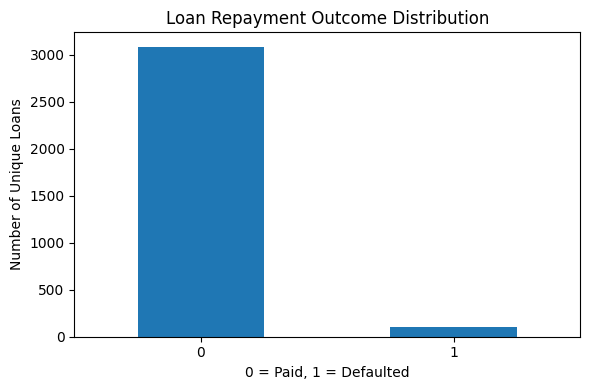

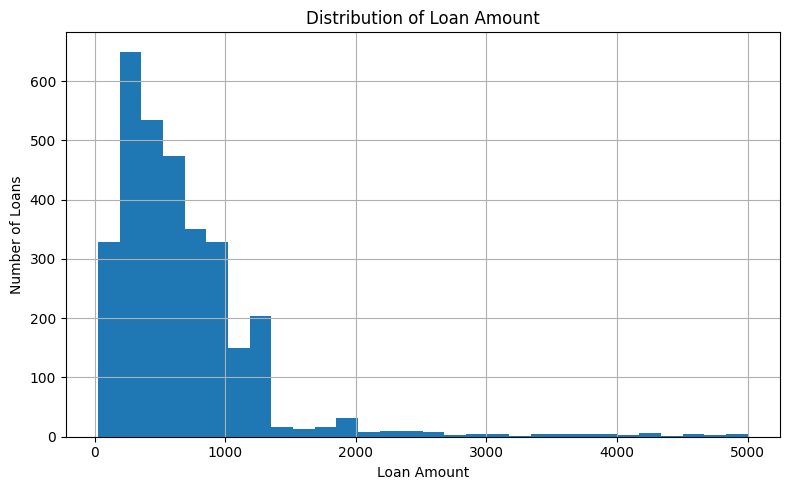

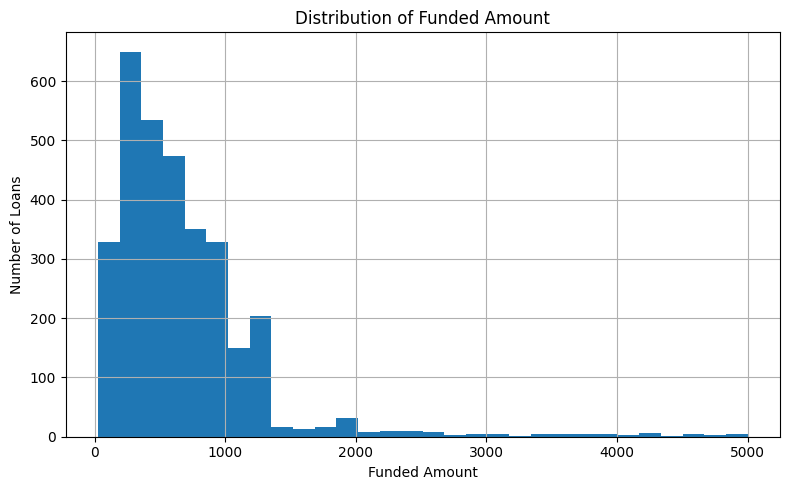

Default rate by sector:


,loan_count,default_count,default_rate,default_rate_percent
sector,,,,
entertainment,3,1,0.333333,33.33
education,4,1,0.250000,25.00
construction,77,8,0.103896,10.39
manufacturing,35,2,0.057143,5.71
services,279,15,0.053763,5.38
clothing,280,12,0.042857,4.29
agriculture,542,18,0.033210,3.32
retail,726,22,0.030303,3.03
food,970,20,0.020619,2.06


Default rate by country with at least 30 loans:


,loan_count,default_count,default_rate,default_rate_percent
location.country,,,,
kenya,82,60,0.731707,73.17
ecuador,58,25,0.431034,43.10
dominican republic,53,11,0.207547,20.75
togo,89,2,0.022472,2.25
mexico,148,1,0.006757,0.68
azerbaijan,108,0,0.000000,0.00
philippines,190,0,0.000000,0.00
ukraine,53,0,0.000000,0.00
uganda,85,0,0.000000,0.00


Default rate by borrower gender group:


,loan_count,default_count,default_rate,default_rate_percent
borrower_gender_group,,,,
m,641,26,0.040562,4.06
f,2541,74,0.029122,2.91


In [28]:
print("Final loan-level dataset shape:")
print(df_model.shape)

print("Final modelling columns:")
print(df_model.columns.tolist())

print("Loan-level target counts:")
print(df_model[TARGET_COLUMN].value_counts().sort_index())

print("Loan-level target percentages:")
print(df_model[TARGET_COLUMN].value_counts(normalize=True).sort_index().mul(100).round(2))


plt.figure(figsize=(6, 4))

df_model[TARGET_COLUMN].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Loan Repayment Outcome Distribution")
plt.xlabel("0 = Paid, 1 = Defaulted")
plt.ylabel("Number of Unique Loans")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

df_model["terms.loan_amount"].hist(bins=30)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

df_model["funded_amount"].hist(bins=30)

plt.title("Distribution of Funded Amount")
plt.xlabel("Funded Amount")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()



sector_summary = (df_model.groupby("sector")[TARGET_COLUMN].agg(loan_count="count",default_count="sum",default_rate="mean")
    .sort_values("default_rate",ascending=False))

sector_summary["default_rate_percent"] = (sector_summary["default_rate"] * 100).round(2)

print("Default rate by sector:")
display(sector_summary)



country_summary = (df_model.groupby("location.country")[TARGET_COLUMN].agg(
        loan_count="count",
        default_count="sum",
        default_rate="mean"
    )
)

country_summary = country_summary[country_summary["loan_count"] >= 30].sort_values("default_rate",ascending=False)

country_summary["default_rate_percent"] = (country_summary["default_rate"] * 100).round(2)

print("Default rate by country with at least 30 loans:")
display(country_summary.head(20))



gender_summary = (df_model.groupby("borrower_gender_group")[TARGET_COLUMN]
    .agg(
        loan_count="count",
        default_count="sum",
        default_rate="mean"
    ).sort_values(
        "default_rate",
        ascending=False
    )
)

gender_summary["default_rate_percent"] = (gender_summary["default_rate"] * 100).round(2)

print("Default rate by borrower gender group:")
display(gender_summary)

In [29]:
# PART 15: IDENTIFY MISSING VALUES

In [30]:
missing_summary = pd.DataFrame({"non_null_count": df_model.notna().sum(),"missing_count":df_model.isna().sum(),
                                "missing_percent": (df_model.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values("missing_percent",ascending=False)

print("Loan-level missing-value summary:")
display(missing_summary)

Loan-level missing-value summary:


,non_null_count,missing_count,missing_percent
description.languages,1955,1227,38.56
terms.loss_liability.currency_exchange,2204,978,30.74
location.town,3119,63,1.98
location.country_code,3176,6,0.19
terms.loss_liability.nonpayment,3182,0,0.00
disbursal_month,3182,0,0.00
disbursal_year,3182,0,0.00
posted_quarter,3182,0,0.00
posted_dayofweek,3182,0,0.00
posted_month,3182,0,0.00


In [31]:
# PART 16: IDENTIFY OUTLIERS

In [32]:
numeric_columns = (df_model.select_dtypes(include=["number"]).columns.drop(TARGET_COLUMN, errors="ignore").tolist())

def create_iqr_outlier_summary(data,columns):
    results = []

    for column in columns:
        series = data[column].dropna()

        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_mask = (
            (series < lower_bound)
            | (series > upper_bound)
        )

        results.append({
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count":
                int(outlier_mask.sum()),
            "outlier_percent":
                round(
                    outlier_mask.mean() * 100,
                    2
                )
        })

    return pd.DataFrame(results)

outlier_summary = create_iqr_outlier_summary(df_model,numeric_columns)

print("IQR outlier summary:")
display(outlier_summary.sort_values("outlier_percent",ascending=False))



invalid_latitude_mask = ((df_model["lat"] < -90) | (df_model["lat"] > 90))

print("Invalid latitude values:")
print(invalid_latitude_mask.sum())

df_model.loc[invalid_latitude_mask,"lat"] = np.nan


invalid_longitude_mask = ((df_model["lon"] < -180) | (df_model["lon"] > 180))

print("Invalid longitude values:")
print(invalid_longitude_mask.sum())

df_model.loc[invalid_longitude_mask,"lon"] = np.nan


IQR outlier summary:


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
3,terms.disbursal_amount,750.000000,21000.000000,20250.000000,-29625.000000,51375.000000,682,21.43
0,funded_amount,325.000000,900.000000,575.000000,-537.500000,1762.500000,129,4.05
4,terms.loan_amount,325.000000,900.000000,575.000000,-537.500000,1762.500000,129,4.05
5,lat,-6.812500,14.750000,21.562500,-39.156251,47.093750,45,1.41
11,disbursal_year,2007.000000,2008.000000,1.000000,2005.500000,2009.500000,9,0.28
2,borrowers.pictured,1.000000,1.000000,0.000000,1.000000,1.000000,3,0.09
1,partner_id,26.000000,88.000000,62.000000,-67.000000,181.000000,0,0.00
6,lon,-75.233333,69.006389,144.239722,-291.592916,285.365972,0,0.00
7,posted_year,2007.000000,2009.000000,2.000000,2004.000000,2012.000000,0,0.00
8,posted_month,3.000000,9.000000,6.000000,-6.000000,18.000000,0,0.00


Invalid latitude values:
0
Invalid longitude values:
0


In [33]:
# PART 17: SEPARATE FEATURES AND TARGET

In [34]:
X = df_model.drop(columns=[TARGET_COLUMN]).copy()

y = (df_model[TARGET_COLUMN].astype(int).copy())

print("Feature matrix shape:")
print(X.shape)

print("Target vector shape:")
print(y.shape)

print("Target counts:")
print(y.value_counts().sort_index())

print("Target proportions:")
print(y.value_counts(normalize=True).sort_index().round(4))

Feature matrix shape:
(3182, 25)
Target vector shape:
(3182,)
Target counts:
repayment_risk
0    3082
1     100
Name: count, dtype: int64
Target proportions:
repayment_risk
0    0.9686
1    0.0314
Name: proportion, dtype: float64


In [35]:
# PART 18: SPLIT THE DATA

In [36]:


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=TEST_SIZE,stratify=y,random_state=RANDOM_STATE)

print("Training feature shape:")
print(X_train.shape)

print("Test feature shape:")
print(X_test.shape)

print("Training target counts:")
print(y_train.value_counts().sort_index())

print("Test target counts:")
print(y_test.value_counts().sort_index())

print("Training target proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("Test target proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Training feature shape:
(2545, 25)
Test feature shape:
(637, 25)
Training target counts:
repayment_risk
0    2465
1      80
Name: count, dtype: int64
Test target counts:
repayment_risk
0    617
1     20
Name: count, dtype: int64
Training target proportions:
repayment_risk
0    0.9686
1    0.0314
Name: proportion, dtype: float64
Test target proportions:
repayment_risk
0    0.9686
1    0.0314
Name: proportion, dtype: float64


In [37]:
#PREVENT GROUP LEAKAGE

In [38]:
# Group leakage is prevented because:
# 1. Payment transactions were aggregated using loan ID.
# 2. Each row in df_model now represents one unique loan.
# 3. The ID column was removed before splitting.
#
# Verify that the original loan-level table has one row per ID.

assert df_loan["id"].is_unique, ("Loan-level table still contains duplicate IDs.")

assert len(df_loan) == len(df_model), ("Unexpected row mismatch after removing ID.")

print("\nGroup leakage check passed: ""each modelling row represents one unique loan.")


Group leakage check passed: each modelling row represents one unique loan.


In [39]:
# PART 20: IMPORT MODELLING LIBRARIES

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("Modelling libraries imported successfully.")


Modelling libraries imported successfully.


In [40]:
numeric_features = (
    X_train
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ---------------------------------------------------------
# FIX pd.NA / sklearn SimpleImputer compatibility problem
# ---------------------------------------------------------

X_train = X_train.copy()
X_test = X_test.copy()

# Convert categorical missing values from pd.NA -> np.nan
for col in categorical_features:
    X_train[col] = X_train[col].astype(object)
    X_test[col] = X_test[col].astype(object)

    X_train[col] = X_train[col].where(
        X_train[col].notna(),
        np.nan
    )

    X_test[col] = X_test[col].where(
        X_test[col].notna(),
        np.nan
    )


# Make numeric columns safe too
for col in numeric_features:
    X_train[col] = pd.to_numeric(
        X_train[col],
        errors="coerce"
    )

    X_test[col] = pd.to_numeric(
        X_test[col],
        errors="coerce"
    )


# ---------------------------------------------------------
# Numeric pipeline
# ---------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ---------------------------------------------------------
# Categorical pipeline
# ---------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
                missing_values=np.nan
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20
            )
        )
    ]
)


# ---------------------------------------------------------
# Combine both
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("\nPreprocessor created.")

Number of numeric features: 14
Number of categorical features: 11

Numeric features:
['funded_amount', 'partner_id', 'borrowers.pictured', 'terms.disbursal_amount', 'terms.loan_amount', 'lat', 'lon', 'posted_year', 'posted_month', 'posted_dayofweek', 'posted_quarter', 'disbursal_year', 'disbursal_month', 'disbursal_dayofweek']

Categorical features:
['description.languages', 'activity', 'sector', 'location.country_code', 'location.country', 'location.town', 'location.geo.level', 'borrower_gender_group', 'terms.disbursal_currency', 'terms.loss_liability.nonpayment', 'terms.loss_liability.currency_exchange']

Preprocessor created.


In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Get the transformed feature names for later feature-importance analysis.
feature_names = preprocessor.get_feature_names_out()
print("Number of transformed features:", len(feature_names))


Processed training shape: (2545, 169)
Processed test shape: (637, 169)
Number of transformed features: 169


In [42]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().sort_index())

minority_count = int(y_train.value_counts().min())

# SMOTE normally uses 5 nearest neighbours. If the minority class is very small,
# reduce k_neighbors automatically so the code still runs safely.
smote_k = min(5, minority_count - 1)

if smote_k < 1:
    raise ValueError(
        "The training set contains fewer than 2 minority-class examples, "
        "so SMOTE cannot be applied."
    )

smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=smote_k
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

print("\nBalanced training feature shape:")
print(X_train_smote.shape)

print("\nUntouched test target distribution:")
print(y_test.value_counts().sort_index())


Class distribution BEFORE SMOTE:
repayment_risk
0    2465
1      80
Name: count, dtype: int64

Class distribution AFTER SMOTE:
repayment_risk
0    2465
1    2465
Name: count, dtype: int64

Balanced training feature shape:
(4930, 169)

Untouched test target distribution:
repayment_risk
0    617
1     20
Name: count, dtype: int64


In [43]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False
    )
}

print("Models prepared:")
for name in models:
    print("-", name)


Models prepared:
- Logistic Regression
- Random Forest
- XGBoost
- CatBoost


In [44]:
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_smote, y_train_smote)
    trained_models[model_name] = model

print("\nAll four main classifiers have been trained.")


Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training CatBoost...

All four main classifiers have been trained.


In [45]:
maximum_svd_components = min(
    100,
    X_train_smote.shape[1] - 1,
    X_train_smote.shape[0] - 1
)

if maximum_svd_components < 2:
    raise ValueError("Not enough transformed dimensions to run TruncatedSVD.")

svd = TruncatedSVD(
    n_components=maximum_svd_components,
    random_state=RANDOM_STATE
)

X_train_svd = svd.fit_transform(X_train_smote)
X_test_svd = svd.transform(X_test_processed)

svd_logistic = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

svd_logistic.fit(X_train_svd, y_train_smote)

trained_models["SVD + Logistic Regression"] = svd_logistic

print("SVD components used:", maximum_svd_components)
print(
    "Cumulative explained variance ratio:",
    round(float(svd.explained_variance_ratio_.sum()), 4)
)
print("SVD + Logistic Regression trained successfully.")


SVD components used: 100
Cumulative explained variance ratio: 0.9966
SVD + Logistic Regression trained successfully.


In [46]:
def evaluate_binary_classifier(
    model_name,
    model,
    X_eval,
    y_true
):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_probability = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probability = model.decision_function(X_eval)
    else:
        y_probability = None

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": (
            roc_auc_score(y_true, y_probability)
            if y_probability is not None
            else np.nan
        )
    }

    return result, y_pred, y_probability


In [47]:
evaluation_results = []
predictions = {}
probabilities = {}

for model_name, model in trained_models.items():
    if model_name == "SVD + Logistic Regression":
        X_eval = X_test_svd
    else:
        X_eval = X_test_processed

    result, y_pred, y_probability = evaluate_binary_classifier(
        model_name,
        model,
        X_eval,
        y_test
    )

    evaluation_results.append(result)
    predictions[model_name] = y_pred
    probabilities[model_name] = y_probability

results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(
    by=["f1", "recall", "roc_auc"],
    ascending=False
).reset_index(drop=True)

metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results_df[metric_columns] = results_df[metric_columns].round(4)

print("Model comparison — all models trained AFTER SMOTE:")
display(results_df)


Model comparison — all models trained AFTER SMOTE:


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9937,0.9444,0.85,0.8947,0.9991
1,CatBoost,0.9922,0.8571,0.90,0.8780,0.9992
2,Random Forest,0.9922,0.8947,0.85,0.8718,0.9988
3,SVD + Logistic Regression,0.9812,0.6333,0.95,0.7600,0.9954
4,Logistic Regression,0.9796,0.6207,0.90,0.7347,0.9950


In [48]:
best_model_name = results_df.iloc[0]["model"]

print("Best model based on F1, then recall, then ROC-AUC:")
print(best_model_name)

print("\nBest-model metrics:")
display(results_df.iloc[[0]])


Best model based on F1, then recall, then ROC-AUC:
XGBoost

Best-model metrics:


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9937,0.9444,0.85,0.8947,0.9991


In [49]:
for model_name in results_df["model"]:
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=["Paid", "Defaulted"],
            zero_division=0
        )
    )


XGBoost
              precision    recall  f1-score   support

        Paid       1.00      1.00      1.00       617
   Defaulted       0.94      0.85      0.89        20

    accuracy                           0.99       637
   macro avg       0.97      0.92      0.95       637
weighted avg       0.99      0.99      0.99       637

CatBoost
              precision    recall  f1-score   support

        Paid       1.00      1.00      1.00       617
   Defaulted       0.86      0.90      0.88        20

    accuracy                           0.99       637
   macro avg       0.93      0.95      0.94       637
weighted avg       0.99      0.99      0.99       637

Random Forest
              precision    recall  f1-score   support

        Paid       1.00      1.00      1.00       617
   Defaulted       0.89      0.85      0.87        20

    accuracy                           0.99       637
   macro avg       0.94      0.92      0.93       637
weighted avg       0.99      0.99      0.99

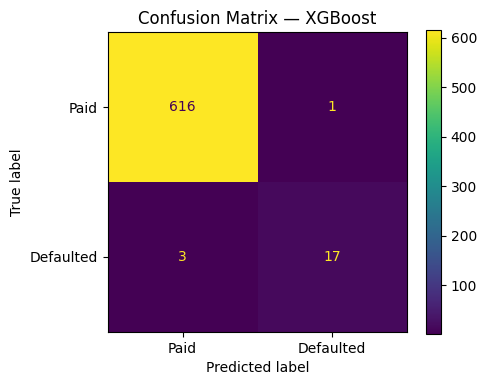

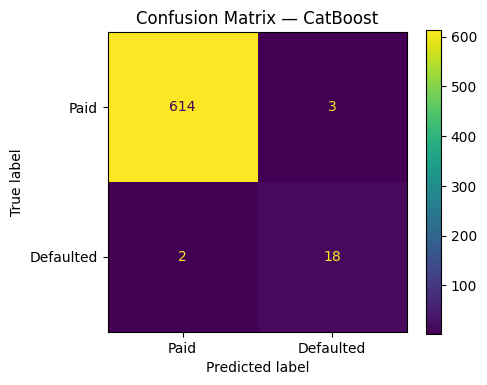

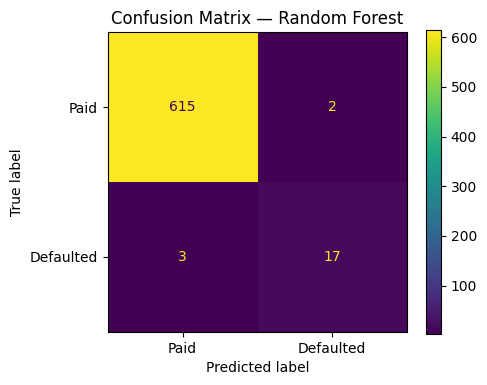

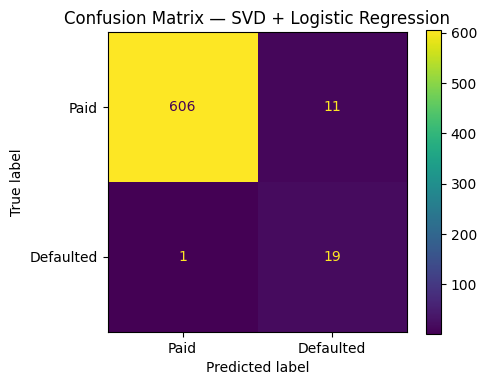

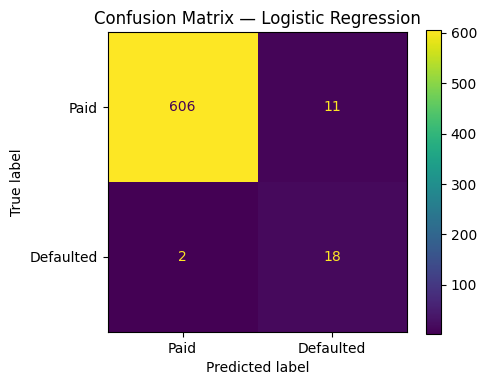

In [50]:
for model_name in results_df["model"]:
    cm = confusion_matrix(y_test, predictions[model_name])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Paid", "Defaulted"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


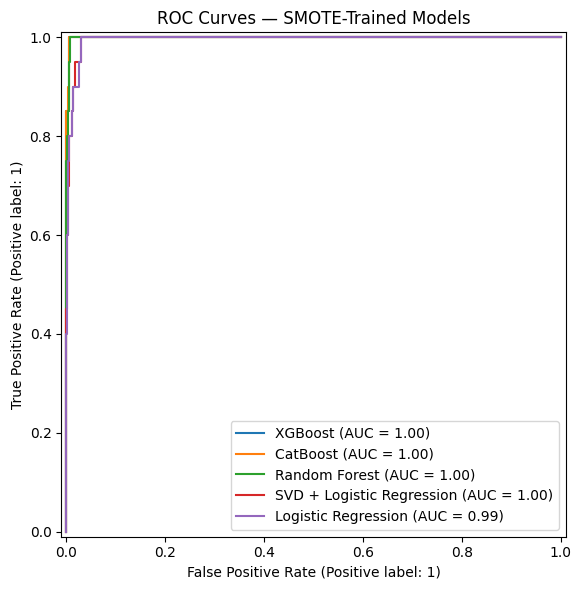

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in results_df["model"]:
    y_probability = probabilities[model_name]

    if y_probability is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_probability,
            name=model_name,
            ax=ax
        )

ax.set_title("ROC Curves — SMOTE-Trained Models")
plt.tight_layout()
plt.show()


## Important note about feature importance

The earlier tree `feature_importances_` values are useful for inspecting a fitted model, but they should **not be treated as the final research interpretation**.

Several predictors contain overlapping information. For example:

- `location.country` and `location.country_code` describe the same country.
- `terms.disbursal_currency` is strongly related to country.
- `lat`, `lon`, `location.town`, and country variables all represent geography.
- `activity` is nested within the broader `sector`.

Tree impurity/gain importances can also be biased toward variables with many possible split points or many one-hot encoded categories.

For the research-facing interpretation below, the notebook therefore adds **test-set permutation importance on the original input columns** and a **conceptual grouped-importance view**. Permutation importance should still be interpreted as predictive association, not causation.



Top transformed features — Random Forest


,feature,importance
0,categorical__terms.loss_liability.nonpayment_p...,0.128423
1,categorical__terms.loss_liability.nonpayment_l...,0.121304
2,categorical__location.country_kenya,0.074607
3,categorical__location.country_code_ke,0.072939
4,numeric__partner_id,0.058203
5,numeric__lat,0.052239
6,numeric__disbursal_year,0.043265
7,numeric__posted_year,0.041464
8,numeric__lon,0.037960
9,categorical__terms.disbursal_currency_usd,0.037209


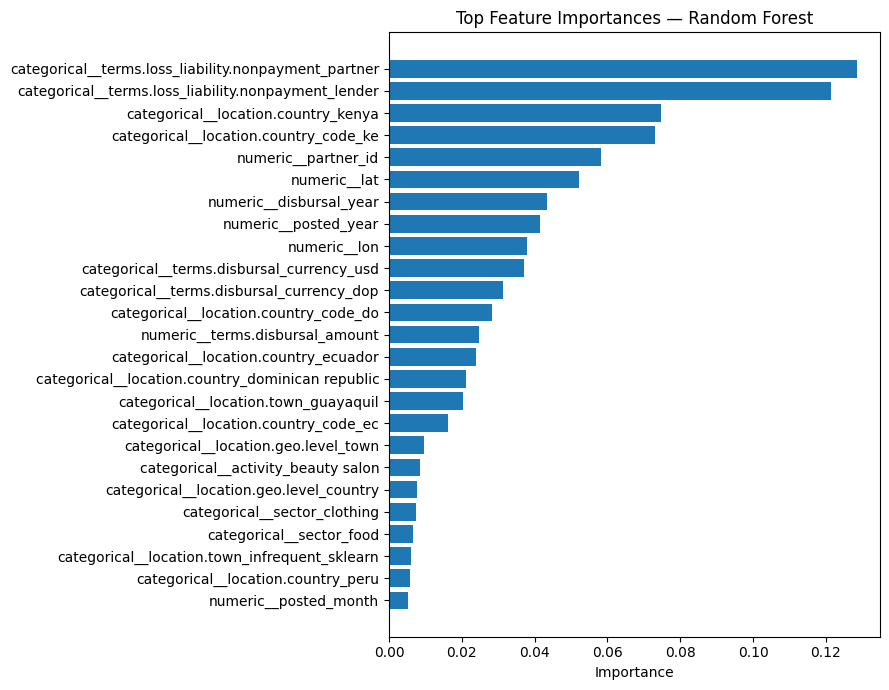


Top transformed features — XGBoost


,feature,importance
0,categorical__terms.loss_liability.nonpayment_l...,0.237801
1,categorical__terms.loss_liability.nonpayment_p...,0.166709
2,categorical__terms.disbursal_currency_dop,0.088410
3,categorical__location.country_code_do,0.075922
4,categorical__location.country_dominican republic,0.075434
5,categorical__terms.disbursal_currency_usd,0.058777
6,numeric__partner_id,0.047685
7,categorical__location.country_code_ec,0.033551
8,categorical__location.country_code_ke,0.023981
9,numeric__disbursal_year,0.020779


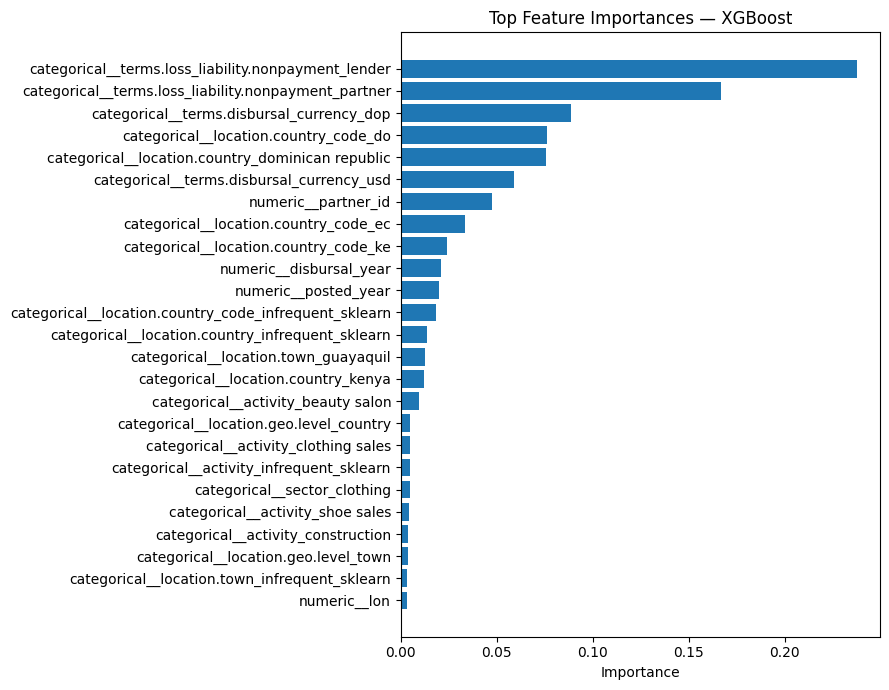


Top transformed features — CatBoost


,feature,importance
0,categorical__terms.loss_liability.nonpayment_l...,17.405455
1,categorical__terms.loss_liability.nonpayment_p...,12.087293
2,categorical__terms.disbursal_currency_dop,7.234296
3,categorical__location.country_kenya,7.158809
4,numeric__partner_id,7.067957
5,categorical__location.country_code_ke,6.592860
6,categorical__location.country_dominican republic,5.892743
7,categorical__location.country_code_do,4.998811
8,categorical__location.town_guayaquil,4.521612
9,numeric__posted_year,3.542420


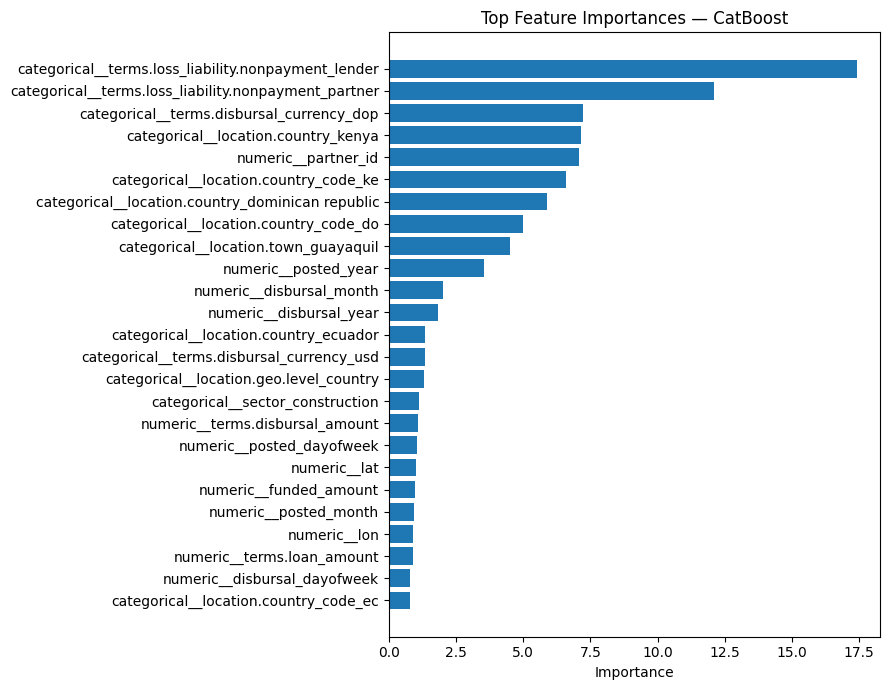

In [52]:
def get_tree_feature_importance(model, feature_names, top_n=25):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    return (
        importance_df
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

for model_name in ["Random Forest", "XGBoost", "CatBoost"]:
    model = trained_models[model_name]
    top_features = get_tree_feature_importance(
        model,
        feature_names,
        top_n=25
    )

    print("\nTop transformed features —", model_name)
    display(top_features)

    plt.figure(figsize=(9, 7))
    plot_df = top_features.sort_values("importance", ascending=True)
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Top Feature Importances — {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


In [53]:
logistic_model = trained_models["Logistic Regression"]

logistic_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

logistic_coefficients["absolute_coefficient"] = (
    logistic_coefficients["coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
).reset_index(drop=True)

print("Top Logistic Regression coefficients by absolute magnitude:")
display(logistic_coefficients.head(25))


Top Logistic Regression coefficients by absolute magnitude:


,feature,coefficient,absolute_coefficient
0,categorical__terms.disbursal_currency_dop,3.489125,3.489125
1,categorical__location.country_code_ke,3.174415,3.174415
2,categorical__location.country_kenya,3.174415,3.174415
3,categorical__terms.loss_liability.nonpayment_p...,-2.964993,2.964993
4,categorical__terms.loss_liability.nonpayment_l...,2.863312,2.863312
5,categorical__location.country_code_do,2.735515,2.735515
6,categorical__location.country_dominican republic,2.735515,2.735515
7,categorical__sector_construction,2.576917,2.576917
8,categorical__location.town_guayaquil,2.088717,2.088717
9,categorical__location.country_ecuador,1.799170,1.799170


In [54]:
svd_component_summary = pd.DataFrame({
    "component": [f"SVD_{i+1}" for i in range(svd.n_components)],
    "explained_variance_ratio": svd.explained_variance_ratio_,
    "logistic_coefficient": svd_logistic.coef_[0]
})

svd_component_summary["absolute_logistic_coefficient"] = (
    svd_component_summary["logistic_coefficient"].abs()
)

print("Total explained variance retained by SVD:")
print(round(float(svd.explained_variance_ratio_.sum()), 4))

print("\nMost influential SVD components in the SVD + Logistic model:")
display(
    svd_component_summary
    .sort_values("absolute_logistic_coefficient", ascending=False)
    .head(20)
)


Total explained variance retained by SVD:
0.9966

Most influential SVD components in the SVD + Logistic model:


,component,explained_variance_ratio,logistic_coefficient,absolute_logistic_coefficient
11,SVD_12,0.019980,4.412760,4.412760
16,SVD_17,0.013286,3.764396,3.764396
22,SVD_23,0.006140,3.308172,3.308172
13,SVD_14,0.016860,2.992946,2.992946
2,SVD_3,0.105676,-2.406733,2.406733
14,SVD_15,0.015736,-2.233036,2.233036
34,SVD_35,0.002763,2.202067,2.202067
29,SVD_30,0.003404,2.103543,2.103543
0,SVD_1,0.094399,-2.028980,2.028980
32,SVD_33,0.002920,-1.948368,1.948368


In [55]:
reconstructed_svd_weights = (
    svd_logistic.coef_[0] @ svd.components_
)

svd_feature_effects = pd.DataFrame({
    "feature": feature_names,
    "approximate_weight": reconstructed_svd_weights
})

svd_feature_effects["absolute_weight"] = (
    svd_feature_effects["approximate_weight"].abs()
)

svd_feature_effects = svd_feature_effects.sort_values(
    "absolute_weight",
    ascending=False
).reset_index(drop=True)

print("Approximate strongest original-feature effects from SVD + Logistic Regression:")
display(svd_feature_effects.head(25))


Approximate strongest original-feature effects from SVD + Logistic Regression:


,feature,approximate_weight,absolute_weight
0,categorical__location.country_code_ke,3.139037,3.139037
1,categorical__location.country_kenya,3.139037,3.139037
2,categorical__terms.disbursal_currency_dop,3.056304,3.056304
3,categorical__terms.loss_liability.nonpayment_p...,-3.014221,3.014221
4,categorical__location.country_dominican republic,2.983737,2.983737
5,categorical__location.country_code_do,2.983737,2.983737
6,categorical__terms.loss_liability.nonpayment_l...,2.838558,2.838558
7,categorical__sector_construction,2.551059,2.551059
8,categorical__location.town_guayaquil,2.481354,2.481354
9,categorical__location.country_ecuador,1.661209,1.661209



Original-variable importance — Random Forest


,model,original_feature,importance
0,Random Forest,terms.loss_liability.nonpayment,0.249727
1,Random Forest,location.country,0.137268
2,Random Forest,location.country_code,0.134587
3,Random Forest,terms.disbursal_currency,0.078681
4,Random Forest,partner_id,0.058203
5,Random Forest,lat,0.052239
6,Random Forest,disbursal_year,0.043265
7,Random Forest,posted_year,0.041464
8,Random Forest,lon,0.037960
9,Random Forest,activity,0.031755


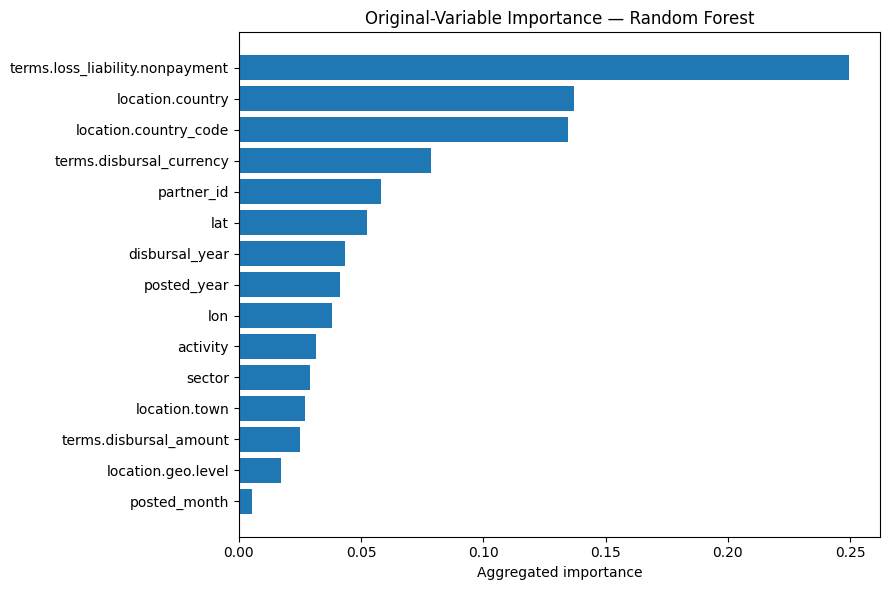


Original-variable importance — XGBoost


,model,original_feature,importance
0,XGBoost,terms.loss_liability.nonpayment,0.404510
1,XGBoost,location.country_code,0.153771
2,XGBoost,terms.disbursal_currency,0.150661
3,XGBoost,location.country,0.104188
4,XGBoost,partner_id,0.047685
5,XGBoost,activity,0.038669
6,XGBoost,disbursal_year,0.020779
7,XGBoost,posted_year,0.020077
8,XGBoost,sector,0.016088
9,XGBoost,location.town,0.015645


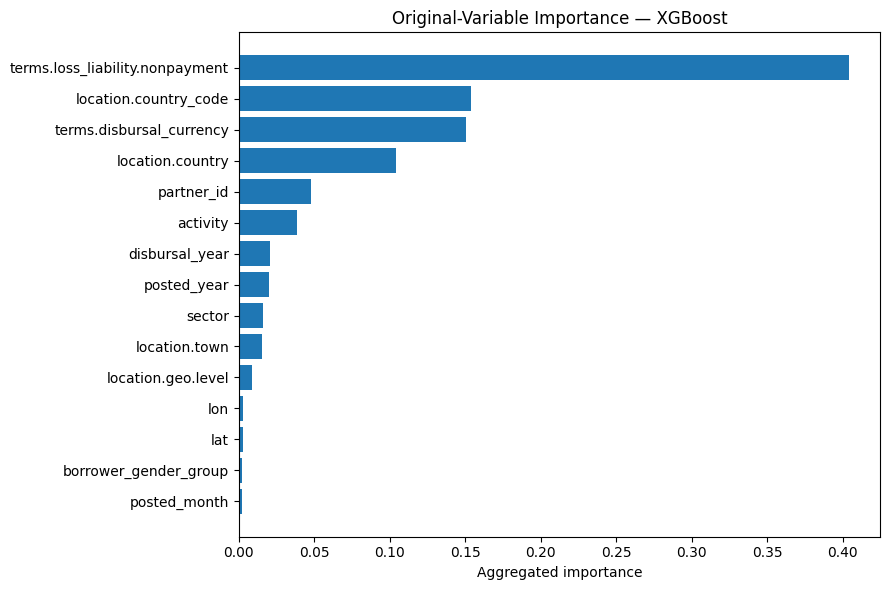


Original-variable importance — CatBoost


,model,original_feature,importance
0,CatBoost,terms.loss_liability.nonpayment,29.492748
1,CatBoost,location.country,14.752083
2,CatBoost,location.country_code,13.052576
3,CatBoost,terms.disbursal_currency,8.736350
4,CatBoost,partner_id,7.067957
5,CatBoost,location.town,4.937946
6,CatBoost,posted_year,3.542420
7,CatBoost,sector,2.107282
8,CatBoost,disbursal_month,2.001616
9,CatBoost,location.geo.level,1.869139


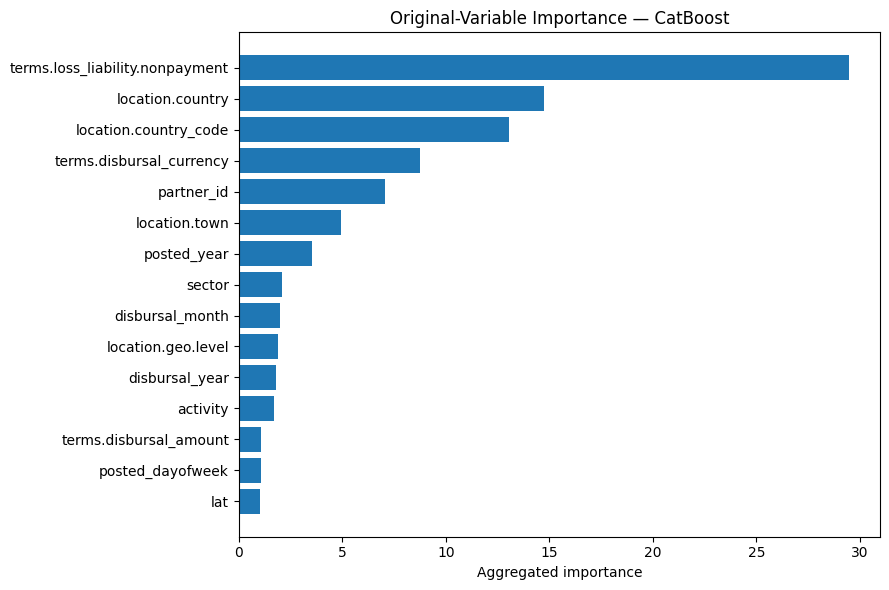

In [56]:
def map_transformed_to_original_feature(transformed_name, original_columns):
    # Remove ColumnTransformer prefixes such as numeric__ and categorical__.
    cleaned = transformed_name.split("__", 1)[-1]

    # Exact match first (mainly numeric variables).
    if cleaned in original_columns:
        return cleaned

    # For one-hot features, choose the longest original column name that
    # forms the prefix before the encoded category value.
    matching_columns = [
        column for column in original_columns
        if cleaned.startswith(column + "_")
    ]

    if matching_columns:
        return max(matching_columns, key=len)

    return cleaned

original_predictor_columns = X_train.columns.tolist()

def aggregate_importance_to_original(model, model_name):
    detailed = pd.DataFrame({
        "transformed_feature": feature_names,
        "importance": model.feature_importances_
    })

    detailed["original_feature"] = detailed["transformed_feature"].apply(
        lambda name: map_transformed_to_original_feature(
            name,
            original_predictor_columns
        )
    )

    aggregated = (
        detailed
        .groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    aggregated.insert(0, "model", model_name)
    return aggregated

aggregated_importance_tables = []

for model_name in ["Random Forest", "XGBoost", "CatBoost"]:
    aggregated = aggregate_importance_to_original(
        trained_models[model_name],
        model_name
    )
    aggregated_importance_tables.append(aggregated)

    print("\nOriginal-variable importance —", model_name)
    display(aggregated.head(20))

    top_plot = aggregated.head(15).sort_values("importance", ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(top_plot["original_feature"], top_plot["importance"])
    plt.title(f"Original-Variable Importance — {model_name}")
    plt.xlabel("Aggregated importance")
    plt.tight_layout()
    plt.show()


In [57]:
rank_tables = []

for table in aggregated_importance_tables:
    temp = table.copy()
    model_name = temp["model"].iloc[0]
    temp["rank"] = temp["importance"].rank(
        method="min",
        ascending=False
    )
    temp = temp[["original_feature", "rank"]].rename(
        columns={"rank": f"rank_{model_name}"}
    )
    rank_tables.append(temp)

consensus_ranking = rank_tables[0]
for table in rank_tables[1:]:
    consensus_ranking = consensus_ranking.merge(
        table,
        on="original_feature",
        how="outer"
    )

rank_columns = [
    column for column in consensus_ranking.columns
    if column.startswith("rank_")
]

consensus_ranking["mean_rank"] = (
    consensus_ranking[rank_columns].mean(axis=1)
)

consensus_ranking = consensus_ranking.sort_values(
    "mean_rank",
    ascending=True
).reset_index(drop=True)

print("Consensus ranking of borrower/loan characteristics:")
display(consensus_ranking.head(20))


Consensus ranking of borrower/loan characteristics:


,original_feature,rank_Random Forest,rank_XGBoost,rank_CatBoost,mean_rank
0,terms.loss_liability.nonpayment,1.0,1.0,1.0,1.000000
1,location.country_code,3.0,2.0,3.0,2.666667
2,location.country,2.0,4.0,2.0,2.666667
3,terms.disbursal_currency,4.0,3.0,4.0,3.666667
4,partner_id,5.0,5.0,5.0,5.000000
5,posted_year,8.0,8.0,7.0,7.666667
6,disbursal_year,7.0,7.0,11.0,8.333333
7,sector,11.0,9.0,8.0,9.333333
8,activity,10.0,6.0,12.0,9.333333
9,location.town,12.0,10.0,6.0,9.333333


In [58]:
print("FINAL MODEL PERFORMANCE")
display(results_df)

print("\nBEST MODEL")
print(best_model_name)

print("\nTOP CONSENSUS BORROWER/LOAN CHARACTERISTICS")
display(consensus_ranking.head(10))

print("\nINTERPRETATION REMINDER")
print(
    "Do not choose a model from accuracy alone. "
    "Discuss F1, recall and ROC-AUC, then use the feature-ranking results "
    "to answer which loan/borrower characteristics are most predictive."
)


FINAL MODEL PERFORMANCE


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9937,0.9444,0.85,0.8947,0.9991
1,CatBoost,0.9922,0.8571,0.90,0.8780,0.9992
2,Random Forest,0.9922,0.8947,0.85,0.8718,0.9988
3,SVD + Logistic Regression,0.9812,0.6333,0.95,0.7600,0.9954
4,Logistic Regression,0.9796,0.6207,0.90,0.7347,0.9950



BEST MODEL
XGBoost

TOP CONSENSUS BORROWER/LOAN CHARACTERISTICS


,original_feature,rank_Random Forest,rank_XGBoost,rank_CatBoost,mean_rank
0,terms.loss_liability.nonpayment,1.0,1.0,1.0,1.000000
1,location.country_code,3.0,2.0,3.0,2.666667
2,location.country,2.0,4.0,2.0,2.666667
3,terms.disbursal_currency,4.0,3.0,4.0,3.666667
4,partner_id,5.0,5.0,5.0,5.000000
5,posted_year,8.0,8.0,7.0,7.666667
6,disbursal_year,7.0,7.0,11.0,8.333333
7,sector,11.0,9.0,8.0,9.333333
8,activity,10.0,6.0,12.0,9.333333
9,location.town,12.0,10.0,6.0,9.333333



INTERPRETATION REMINDER
Do not choose a model from accuracy alone. Discuss F1, recall and ROC-AUC, then use the feature-ranking results to answer which loan/borrower characteristics are most predictive.


In [59]:
# import joblib
#
# joblib.dump(preprocessor, "kiva_preprocessor.joblib")
# joblib.dump(svd, "kiva_svd.joblib")
# joblib.dump(trained_models, "kiva_trained_models.joblib")
# joblib.dump(results_df, "kiva_model_results.joblib")
#
# print("Model artefacts saved.")


# PART 27 — GRID SEARCH CROSS-VALIDATION

This section replaces the manually chosen model parameters with **GridSearchCV**.

### Methodological rule

SMOTE is placed **inside** an `imblearn` pipeline used by GridSearchCV. This is important because each cross-validation fold must create synthetic minority samples using only that fold's training portion. Applying SMOTE once before cross-validation would leak information across folds.

The untouched 20% test set is **never used for hyperparameter selection**. It is used only once after each optimized model has been selected.


In [60]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import time

CV_FOLDS = 5

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Grid-search cross-validation prepared.")
print("CV folds:", CV_FOLDS)
print("Refit metric: F1")


Grid-search cross-validation prepared.
CV folds: 5
Refit metric: F1


## 27.1 Build leakage-safe preprocessing pipelines

Each candidate model receives:

`raw training data → imputation/encoding/scaling → SMOTE → classifier`

The SVD model receives:

`raw training data → imputation/encoding/scaling → SMOTE → TruncatedSVD → Logistic Regression`


In [61]:
def make_preprocessor():
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    missing_values=np.nan
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=20
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )


# GridSearchCV works from the raw train/test DataFrames.
# Normalize pd.NA -> np.nan first.
X_train_grid = X_train.copy()
X_test_grid = X_test.copy()

for col in categorical_features:
    X_train_grid[col] = X_train_grid[col].astype(object)
    X_test_grid[col] = X_test_grid[col].astype(object)

    X_train_grid[col] = X_train_grid[col].where(
        pd.notna(X_train_grid[col]), np.nan
    )
    X_test_grid[col] = X_test_grid[col].where(
        pd.notna(X_test_grid[col]), np.nan
    )

for col in numeric_features:
    X_train_grid[col] = pd.to_numeric(X_train_grid[col], errors="coerce")
    X_test_grid[col] = pd.to_numeric(X_test_grid[col], errors="coerce")

minority_count_grid = int(y_train.value_counts().min())
grid_smote_k = min(5, minority_count_grid - 1)

if grid_smote_k < 1:
    raise ValueError("Not enough minority samples for SMOTE.")

print("Training rows for GridSearchCV:", len(X_train_grid))
print("Test rows kept untouched:", len(X_test_grid))
print("SMOTE k_neighbors:", grid_smote_k)


Training rows for GridSearchCV: 2545
Test rows kept untouched: 637
SMOTE k_neighbors: 5


In [62]:
grid_pipelines = {
    "Logistic Regression": ImbPipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=grid_smote_k)),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest": ImbPipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=grid_smote_k)),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=1
                )
            )
        ]
    ),

    "XGBoost": ImbPipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=grid_smote_k)),
            (
                "model",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=1
                )
            )
        ]
    ),

    "CatBoost": ImbPipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=grid_smote_k)),
            (
                "model",
                CatBoostClassifier(
                    loss_function="Logloss",
                    eval_metric="AUC",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                    thread_count=1
                )
            )
        ]
    ),

    "SVD + Logistic Regression": ImbPipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=grid_smote_k)),
            (
                "svd",
                TruncatedSVD(
                    random_state=RANDOM_STATE
                )
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
}

print("Five GridSearchCV pipelines created.")


Five GridSearchCV pipelines created.


## 27.2 Hyperparameter grids

These are intentionally **moderate grids**. They are large enough to tune important parameters without turning the project into an excessively expensive hyperparameter-search study.

You can expand the grids later if your machine has sufficient time and memory.


In [63]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt"]
    },

    "XGBoost": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.10],
        "model__max_depth": [3, 6],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },

    "CatBoost": {
        "model__iterations": [200, 400],
        "model__learning_rate": [0.03, 0.10],
        "model__depth": [4, 6, 8],
        "model__l2_leaf_reg": [3, 7]
    },

    "SVD + Logistic Regression": {
        "svd__n_components": [25, 50, 100],
        "model__C": [0.1, 1.0, 10.0],
        "model__solver": ["liblinear", "lbfgs"]
    }
}

for model_name, grid in param_grids.items():
    combinations = int(np.prod([len(v) for v in grid.values()]))
    print(f"{model_name}: {combinations} parameter combinations")


Logistic Regression: 6 parameter combinations
Random Forest: 24 parameter combinations
XGBoost: 32 parameter combinations
CatBoost: 24 parameter combinations
SVD + Logistic Regression: 18 parameter combinations


## 27.3 Run GridSearchCV for all five models

The search optimizes **F1-score** because the target is imbalanced and the project is interested in detecting defaults without ignoring precision. Recall and ROC-AUC are retained as additional evaluation metrics.

> This cell can take substantial CPU time. Run it once and save the resulting fitted models.


In [64]:
optimized_searches = {}
grid_search_summary = []

for model_name in grid_pipelines:
    print("\n" + "=" * 90)
    print("GRID SEARCH:", model_name)
    print("=" * 90)

    start_time = time.time()

    search = GridSearchCV(
        estimator=grid_pipelines[model_name],
        param_grid=param_grids[model_name],
        scoring=scoring,
        refit="f1",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train_grid, y_train)

    elapsed_minutes = (time.time() - start_time) / 60

    optimized_searches[model_name] = search

    grid_search_summary.append({
        "model": model_name,
        "best_cv_f1": search.best_score_,
        "best_parameters": search.best_params_,
        "search_minutes": elapsed_minutes
    })

    print("Best CV F1:", round(search.best_score_, 4))
    print("Best parameters:")
    print(search.best_params_)
    print("Search time (minutes):", round(elapsed_minutes, 2))

grid_search_summary_df = pd.DataFrame(grid_search_summary)
display(grid_search_summary_df)



GRID SEARCH: Logistic Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best CV F1: 0.7689
Best parameters:
{'model__C': 10.0, 'model__solver': 'lbfgs'}
Search time (minutes): 0.07

GRID SEARCH: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F1: 0.8787
Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Search time (minutes): 0.31

GRID SEARCH: XGBoost
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV F1: 0.8792
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}
Search time (minutes): 0.14

GRID SEARCH: CatBoost
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F1: 0.8714
Best parameters:
{'model__depth': 6, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_r

,model,best_cv_f1,best_parameters,search_minutes
0,Logistic Regression,0.768921,"{'model__C': 10.0, 'model__solver': 'lbfgs'}",0.065072
1,Random Forest,0.878660,"{'model__max_depth': None, 'model__max_feature...",0.310763
2,XGBoost,0.879159,"{'model__colsample_bytree': 0.8, 'model__learn...",0.140992
3,CatBoost,0.871384,"{'model__depth': 6, 'model__iterations': 200, ...",1.316742
4,SVD + Logistic Regression,0.768921,"{'model__C': 10.0, 'model__solver': 'lbfgs', '...",0.033598


# PART 28 — FINAL TEST-SET EVALUATION OF OPTIMIZED MODELS

Only the best hyperparameters selected from training-fold cross-validation are evaluated here on the untouched test set.


In [65]:
optimized_results = []
optimized_predictions = {}
optimized_probabilities = {}

for model_name, search in optimized_searches.items():
    best_estimator = search.best_estimator_

    y_pred = best_estimator.predict(X_test_grid)

    if hasattr(best_estimator, "predict_proba"):
        y_prob = best_estimator.predict_proba(X_test_grid)[:, 1]
    else:
        y_prob = best_estimator.decision_function(X_test_grid)

    optimized_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    optimized_predictions[model_name] = y_pred
    optimized_probabilities[model_name] = y_prob

optimized_results_df = (
    pd.DataFrame(optimized_results)
    .sort_values(["f1", "recall", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(
    optimized_results_df.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "roc_auc": "{:.4f}"
    })
)

optimized_best_model_name = optimized_results_df.iloc[0]["model"]

print("\nBest optimized model:", optimized_best_model_name)


,model,accuracy,precision,recall,f1,roc_auc
0,CatBoost,0.9953,0.9048,0.9500,0.9268,0.9992
1,XGBoost,0.9953,1.0000,0.8500,0.9189,0.9991
2,Random Forest,0.9922,0.8947,0.8500,0.8718,0.9986
3,SVD + Logistic Regression,0.9827,0.6800,0.8500,0.7556,0.9954
4,Logistic Regression,0.9827,0.6800,0.8500,0.7556,0.9953



Best optimized model: CatBoost


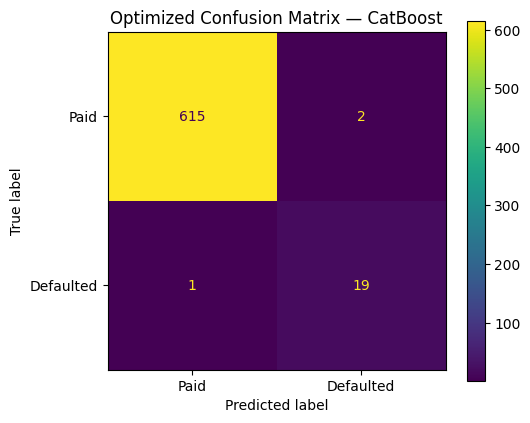

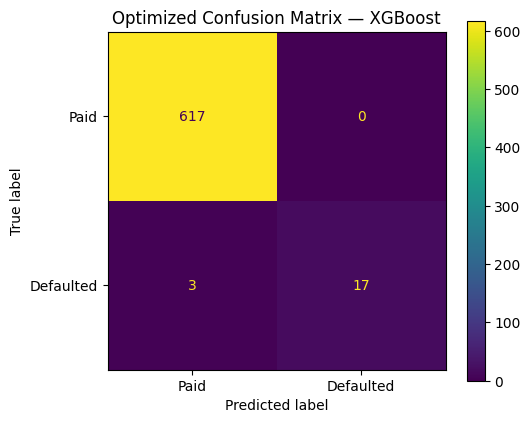

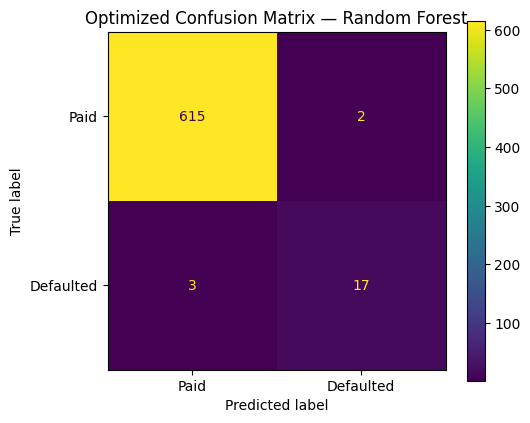

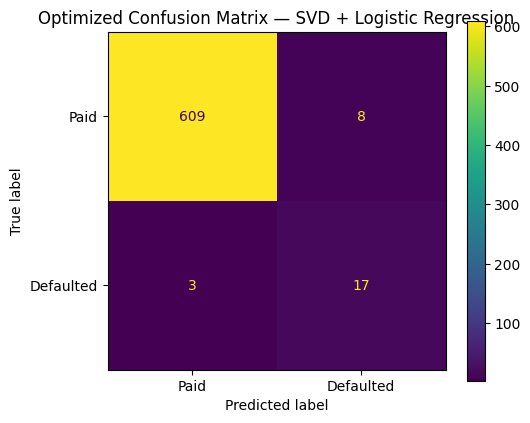

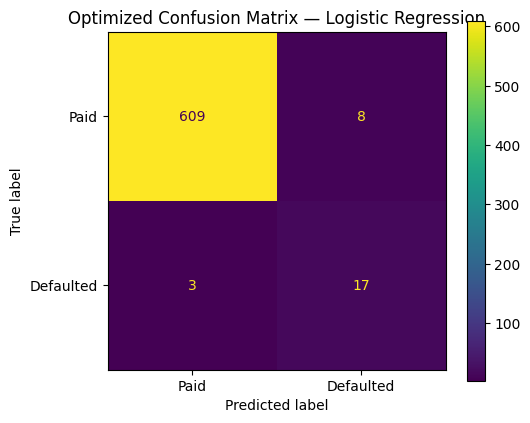

In [66]:
# Confusion matrices for optimized models
for model_name in optimized_results_df["model"]:
    cm = confusion_matrix(
        y_test,
        optimized_predictions[model_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Paid", "Defaulted"]
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"Optimized Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


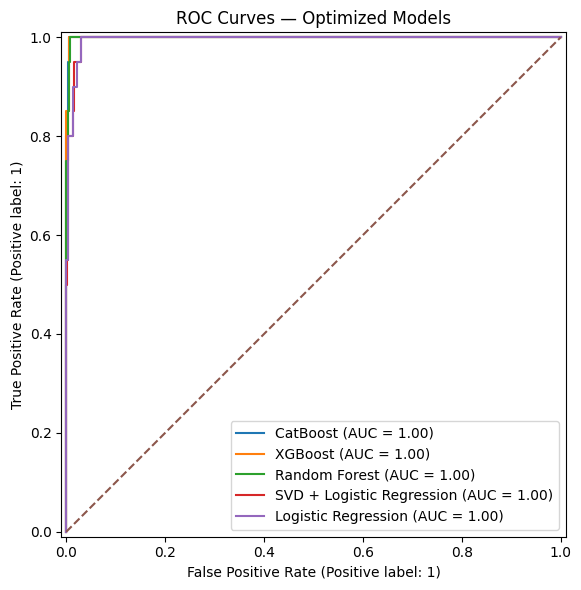

In [67]:
# ROC curves for optimized models
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in optimized_results_df["model"]:
    RocCurveDisplay.from_predictions(
        y_test,
        optimized_probabilities[model_name],
        name=model_name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curves — Optimized Models")
plt.tight_layout()
plt.show()


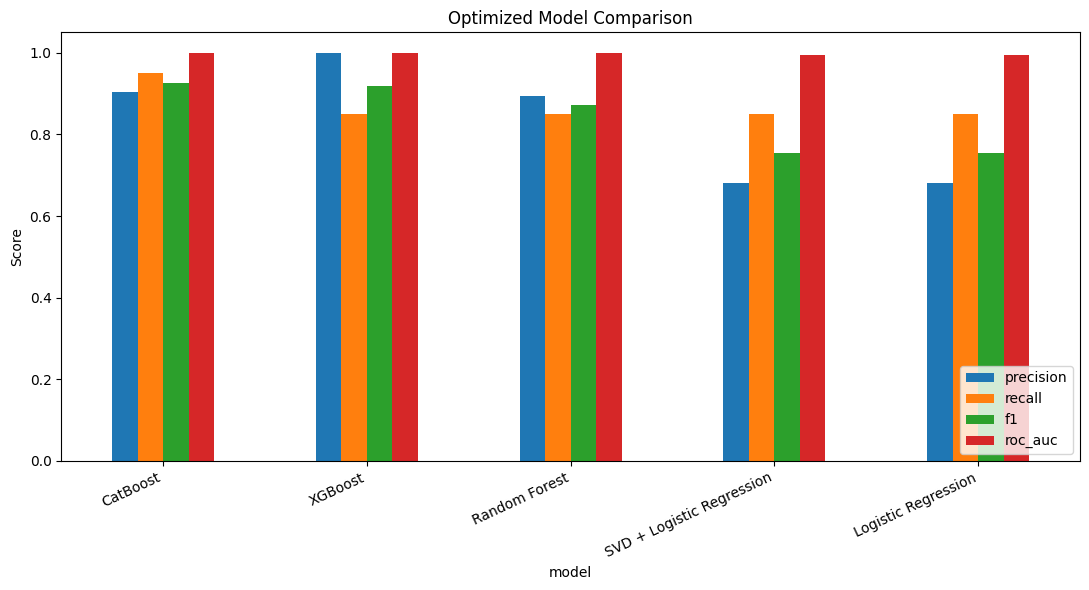

In [68]:
# Model-comparison plot
comparison_plot_df = optimized_results_df.set_index("model")[
    ["precision", "recall", "f1", "roc_auc"]
]

comparison_plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Optimized Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# PART 29 — ROBUST FEATURE IMPORTANCE

## Why this replaces the earlier consensus ranking for interpretation

The earlier RF/XGBoost/CatBoost built-in importance plots can be useful diagnostics, but they can exaggerate variables that have many encoded categories and they separately count highly redundant variables.

This section computes **permutation importance on the untouched test set using the original predictor columns**. A feature is important when randomly shuffling it reduces F1 performance.

Important caution: when two columns contain almost the same information, permutation importance can be shared or diluted between them. Therefore, a second conceptual grouping is also shown.



Permutation importance: Logistic Regression


,feature,importance_mean,importance_std
0,terms.loss_liability.nonpayment,0.340323,0.055938
1,location.country_code,0.127300,0.035448
2,location.country,0.127300,0.035448
3,disbursal_year,0.077566,0.039956
4,disbursal_month,0.070330,0.037786
5,posted_year,0.040469,0.037024
6,posted_quarter,0.037743,0.031359
7,posted_month,0.034794,0.046113
8,sector,0.031924,0.040230
9,location.town,0.020674,0.018541


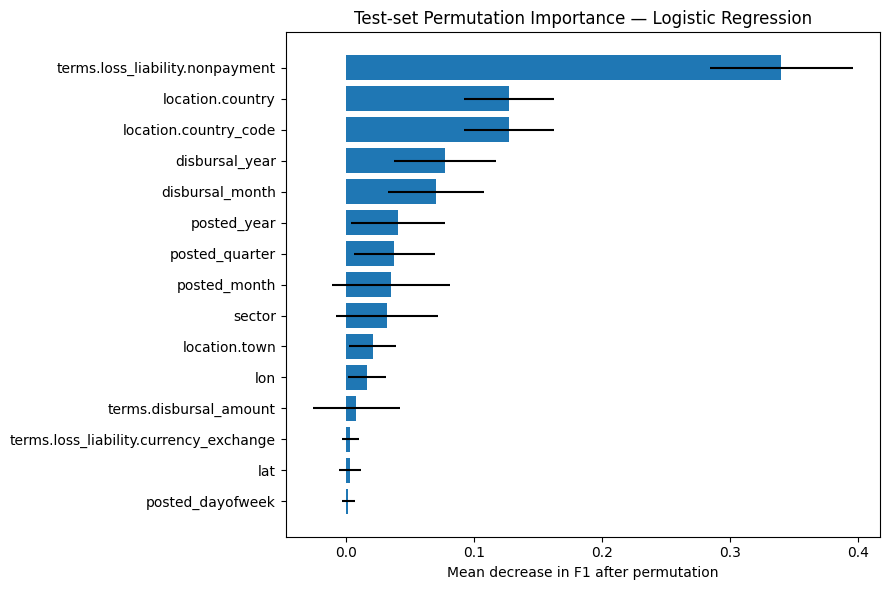


Permutation importance: Random Forest


,feature,importance_mean,importance_std
0,terms.loss_liability.nonpayment,0.586606,0.094206
1,lat,0.047091,0.014221
2,posted_year,0.025298,0.016444
3,location.country_code,0.022610,0.018079
4,location.country,0.022610,0.018079
5,partner_id,0.018745,0.014875
6,disbursal_year,0.016213,0.017985
7,terms.disbursal_currency,0.014153,0.022192
8,disbursal_month,0.008907,0.013605
9,lon,0.007287,0.020118


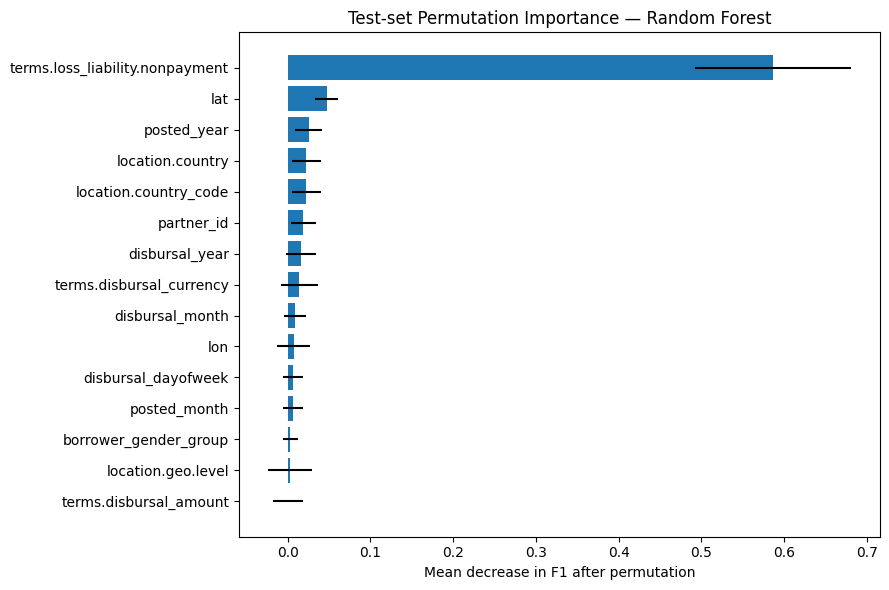


Permutation importance: XGBoost


,feature,importance_mean,importance_std
0,terms.loss_liability.nonpayment,0.553046,0.092453
1,location.country_code,0.169965,0.019449
2,partner_id,0.113641,0.028791
3,terms.disbursal_currency,0.063385,0.007750
4,lon,0.054614,0.013812
5,disbursal_month,0.054205,0.026185
6,posted_year,0.028845,0.012244
7,lat,0.027643,0.021010
8,location.town,0.027027,0.009009
9,posted_month,0.024024,0.012012


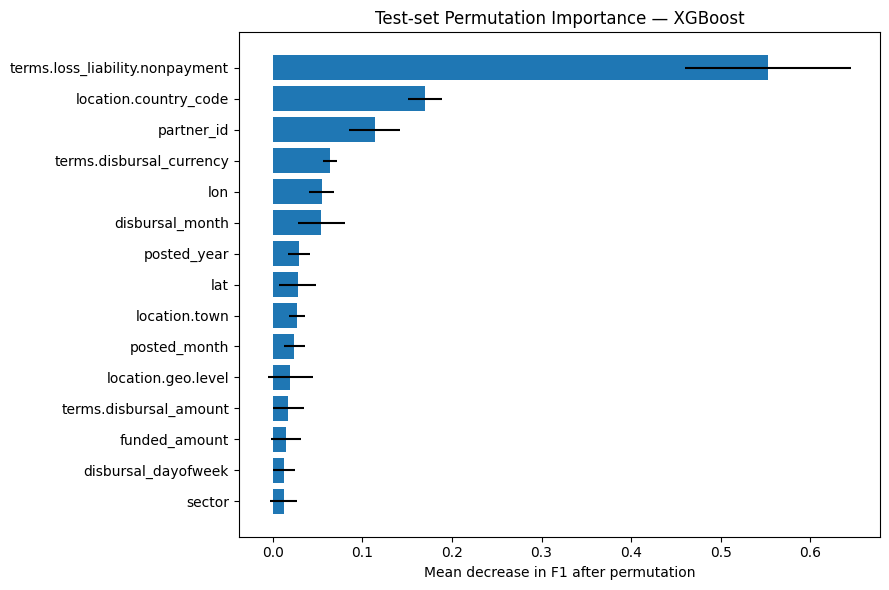


Permutation importance: CatBoost


,feature,importance_mean,importance_std
0,terms.loss_liability.nonpayment,0.567509,0.086949
1,partner_id,0.093112,0.036170
2,terms.disbursal_currency,0.065449,0.021554
3,location.country,0.055279,0.016577
4,disbursal_month,0.051982,0.025428
5,posted_year,0.049803,0.024105
6,disbursal_year,0.035428,0.017783
7,location.town,0.035291,0.012925
8,location.country_code,0.029650,0.008462
9,lat,0.025172,0.023443


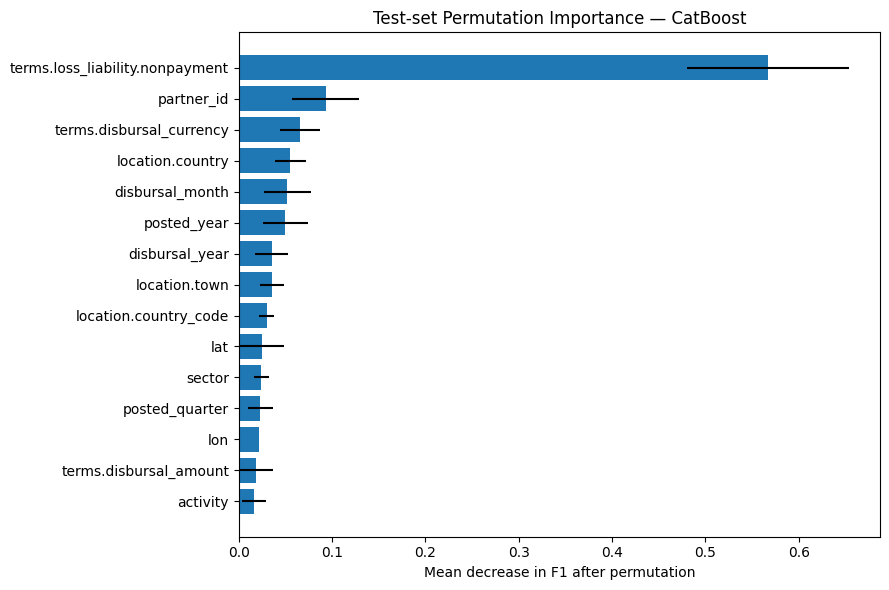


Permutation importance: SVD + Logistic Regression


,feature,importance_mean,importance_std
0,terms.loss_liability.nonpayment,0.341110,0.060343
1,location.country_code,0.135499,0.028263
2,location.country,0.135499,0.028263
3,posted_month,0.070525,0.041330
4,location.town,0.061229,0.029141
5,posted_quarter,0.021280,0.032370
6,disbursal_month,0.017215,0.035292
7,terms.disbursal_amount,0.003469,0.034163
8,lat,0.000531,0.012313
9,sector,0.000172,0.018639


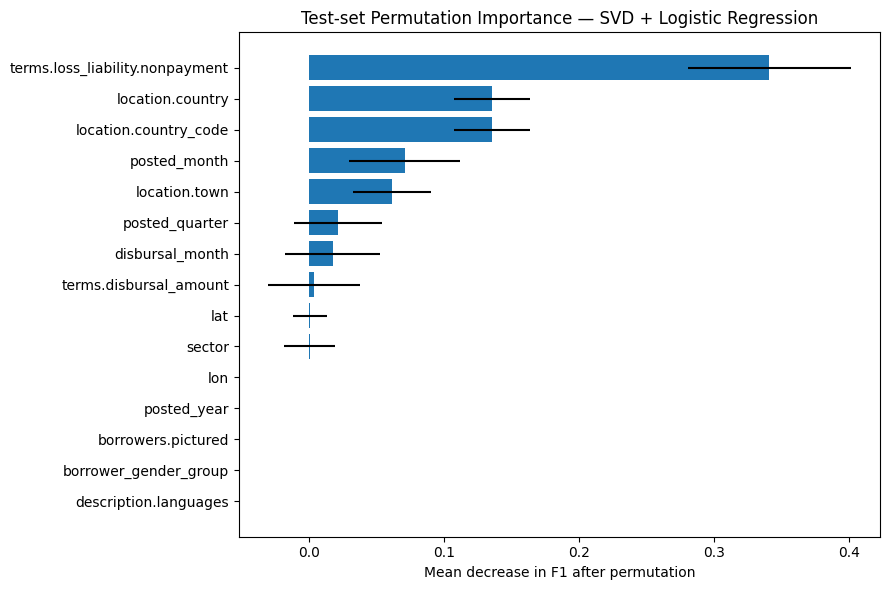

In [69]:
permutation_tables = {}

for model_name, search in optimized_searches.items():
    print("\nPermutation importance:", model_name)

    perm = permutation_importance(
        estimator=search.best_estimator_,
        X=X_test_grid,
        y=y_test,
        scoring="f1",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X_test_grid.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(
        "importance_mean",
        ascending=False
    ).reset_index(drop=True)

    permutation_tables[model_name] = importance_df

    display(importance_df.head(20))

    top_plot = (
        importance_df
        .head(15)
        .sort_values("importance_mean")
    )

    plt.figure(figsize=(9, 6))
    plt.barh(
        top_plot["feature"],
        top_plot["importance_mean"],
        xerr=top_plot["importance_std"]
    )
    plt.title(f"Test-set Permutation Importance — {model_name}")
    plt.xlabel("Mean decrease in F1 after permutation")
    plt.tight_layout()
    plt.show()


In [70]:
# Inspect obvious redundancy/overlap among conceptually related variables.
redundancy_notes = pd.DataFrame({
    "overlapping_features": [
        "location.country + location.country_code",
        "location.country/town + lat/lon",
        "location.country + terms.disbursal_currency",
        "activity + sector",
        "funded_amount + terms.loan_amount + terms.disbursal_amount",
        "posted_year/month + disbursal_year/month"
    ],
    "interpretation": [
        "Two encodings of the same country",
        "Different representations of geography",
        "Currency is strongly linked to geography",
        "Activity is a more detailed business category nested within sector",
        "Different monetary descriptions of the same/related loan",
        "Related timing/cohort information"
    ]
})

display(redundancy_notes)


,overlapping_features,interpretation
0,location.country + location.country_code,Two encodings of the same country
1,location.country/town + lat/lon,Different representations of geography
2,location.country + terms.disbursal_currency,Currency is strongly linked to geography
3,activity + sector,Activity is a more detailed business category ...
4,funded_amount + terms.loan_amount + terms.disb...,Different monetary descriptions of the same/re...
5,posted_year/month + disbursal_year/month,Related timing/cohort information



Conceptual grouped importance — Logistic Regression


,conceptual_group,positive_importance
0,Loss-liability terms,0.343608
1,Geography / location context,0.294316
2,Timing / cohort,0.262545
3,Business type,0.031924
4,Loan size / amount,0.008014
5,Field partner,0.000602
6,Borrower profile,0.000000
7,Description language,0.000000


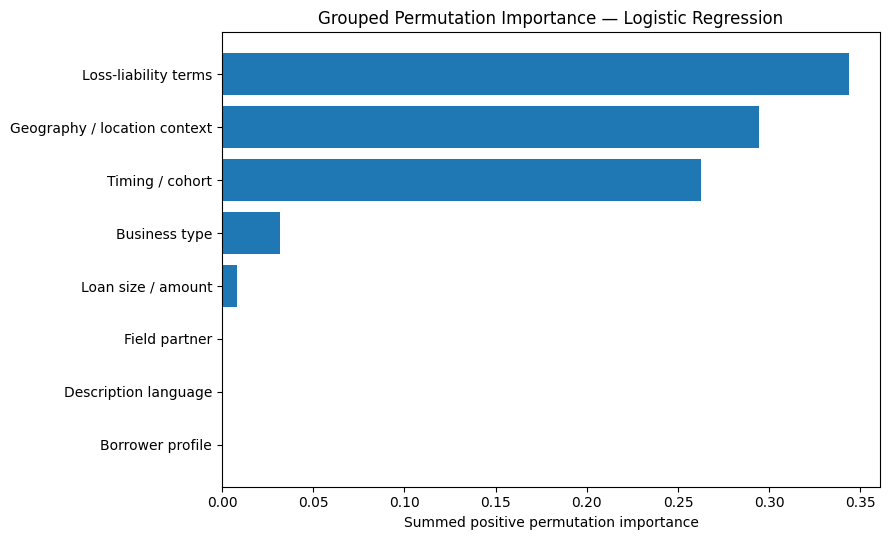


Conceptual grouped importance — Random Forest


,conceptual_group,positive_importance
0,Loss-liability terms,0.586606
1,Geography / location context,0.116604
2,Timing / cohort,0.062293
3,Field partner,0.018745
4,Borrower profile,0.002969
5,Loan size / amount,0.000441
6,Business type,0.000000
7,Description language,0.000000


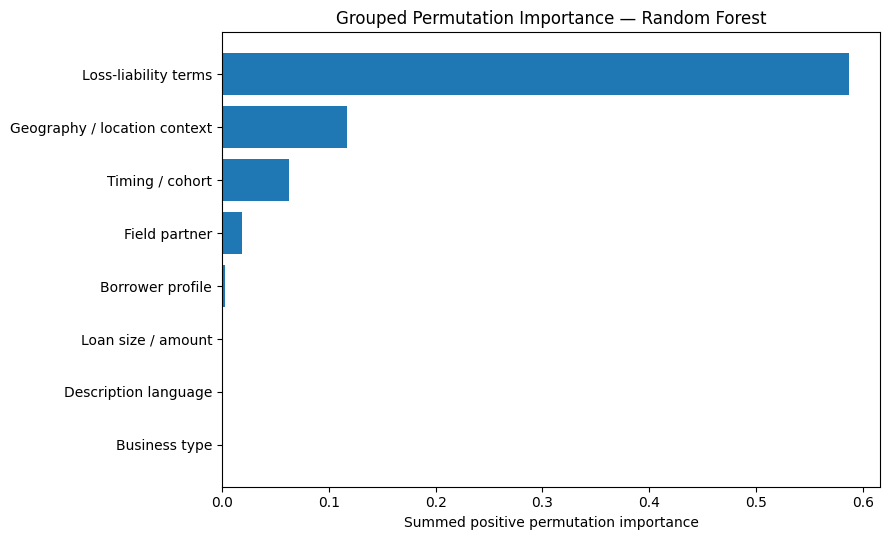


Conceptual grouped importance — XGBoost


,conceptual_group,positive_importance
0,Loss-liability terms,0.553046
1,Geography / location context,0.362028
2,Timing / cohort,0.134180
3,Field partner,0.113641
4,Loan size / amount,0.034643
5,Business type,0.012012
6,Borrower profile,0.000000
7,Description language,0.000000


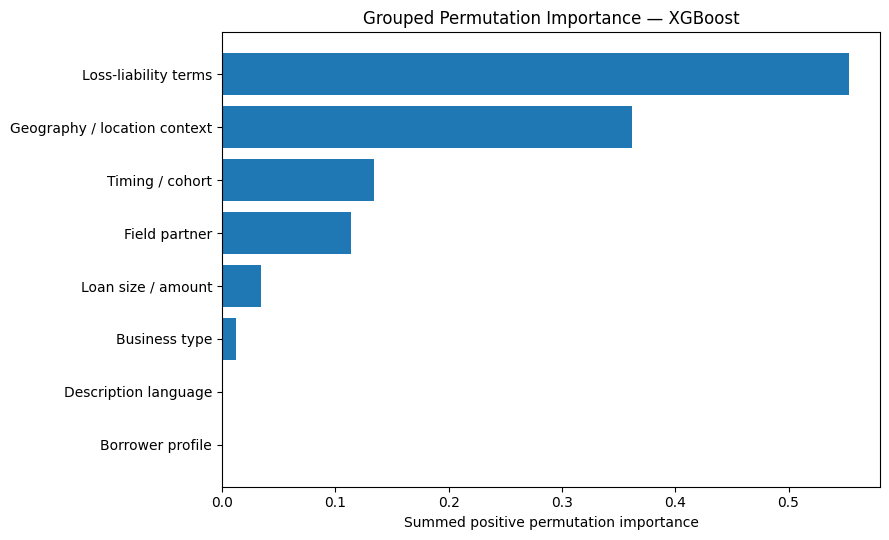


Conceptual grouped importance — CatBoost


,conceptual_group,positive_importance
0,Loss-liability terms,0.567509
1,Geography / location context,0.246323
2,Timing / cohort,0.172847
3,Field partner,0.093112
4,Business type,0.040244
5,Loan size / amount,0.024284
6,Borrower profile,0.000000
7,Description language,0.000000


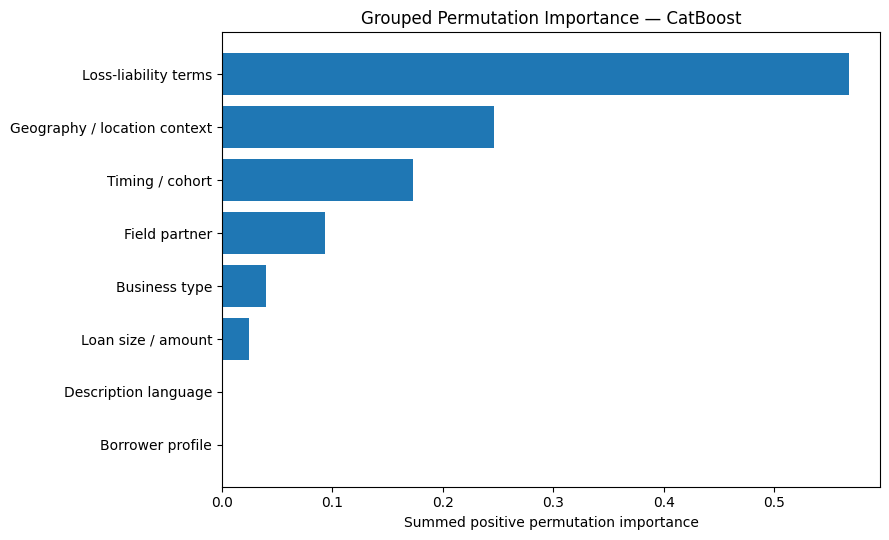


Conceptual grouped importance — SVD + Logistic Regression


,conceptual_group,positive_importance
0,Loss-liability terms,0.341110
1,Geography / location context,0.332759
2,Timing / cohort,0.109020
3,Loan size / amount,0.003469
4,Business type,0.000172
5,Borrower profile,0.000000
6,Description language,0.000000
7,Field partner,0.000000


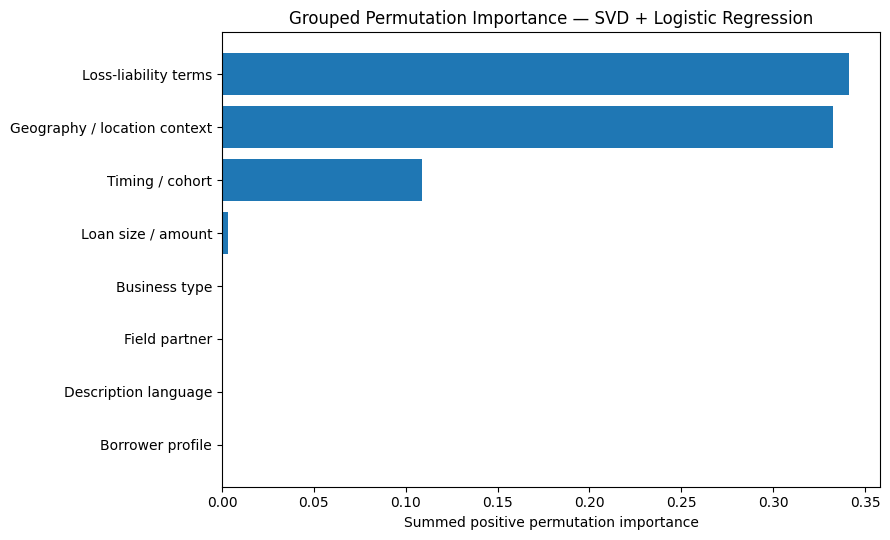

In [71]:
def conceptual_feature_group(feature):
    if feature.startswith("location.") or feature in {
        "lat", "lon", "terms.disbursal_currency"
    }:
        return "Geography / location context"

    if feature.startswith("terms.loss_liability"):
        return "Loss-liability terms"

    if feature in {"activity", "sector"}:
        return "Business type"

    if feature in {
        "funded_amount",
        "terms.loan_amount",
        "terms.disbursal_amount"
    }:
        return "Loan size / amount"

    if feature.startswith("posted_") or feature.startswith("disbursal_"):
        return "Timing / cohort"

    if feature == "partner_id":
        return "Field partner"

    if feature in {
        "borrower_gender_group",
        "borrowers.pictured"
    }:
        return "Borrower profile"

    if feature == "description.languages":
        return "Description language"

    return "Other"


grouped_permutation_tables = {}

for model_name, table in permutation_tables.items():
    temp = table.copy()
    temp["conceptual_group"] = temp["feature"].apply(conceptual_feature_group)

    # Negative permutation values are treated as zero for group-level explanatory summaries.
    temp["positive_importance"] = temp["importance_mean"].clip(lower=0)

    grouped = (
        temp.groupby("conceptual_group", as_index=False)["positive_importance"]
        .sum()
        .sort_values("positive_importance", ascending=False)
        .reset_index(drop=True)
    )

    grouped_permutation_tables[model_name] = grouped

    print("\nConceptual grouped importance —", model_name)
    display(grouped)

    plot_df = grouped.sort_values("positive_importance")
    plt.figure(figsize=(9, 5.5))
    plt.barh(plot_df["conceptual_group"], plot_df["positive_importance"])
    plt.title(f"Grouped Permutation Importance — {model_name}")
    plt.xlabel("Summed positive permutation importance")
    plt.tight_layout()
    plt.show()


## 29.1 Research-facing importance table

Instead of averaging raw tree impurity rankings, this table averages the **ranks of original-column permutation importance across all five optimized models**.

Use it as a robustness summary, while still discussing model-specific differences.


In [72]:
permutation_rank_tables = []

for model_name, table in permutation_tables.items():
    temp = table[["feature", "importance_mean"]].copy()
    temp["rank"] = temp["importance_mean"].rank(
        method="average",
        ascending=False
    )

    temp = temp[["feature", "rank"]].rename(
        columns={"rank": f"rank_{model_name}"}
    )

    permutation_rank_tables.append(temp)

robust_consensus = permutation_rank_tables[0]

for table in permutation_rank_tables[1:]:
    robust_consensus = robust_consensus.merge(
        table,
        on="feature",
        how="outer"
    )

rank_cols = [
    c for c in robust_consensus.columns
    if c.startswith("rank_")
]

robust_consensus["mean_rank"] = (
    robust_consensus[rank_cols]
    .mean(axis=1)
)

robust_consensus = (
    robust_consensus
    .sort_values("mean_rank")
    .reset_index(drop=True)
)

print("Robust consensus using test-set permutation importance:")
display(robust_consensus.head(20))


Robust consensus using test-set permutation importance:


,feature,rank_Logistic Regression,rank_Random Forest,rank_XGBoost,rank_CatBoost,rank_SVD + Logistic Regression,mean_rank
0,terms.loss_liability.nonpayment,1.0,1.0,1.0,1.0,1.0,1.0
1,location.country_code,2.5,4.5,2.0,9.0,2.5,4.1
2,disbursal_month,5.0,9.0,6.0,5.0,7.0,6.4
3,posted_year,6.0,3.0,7.0,6.0,13.5,7.1
4,location.country,2.5,4.5,22.0,4.0,2.5,7.1
5,lat,14.0,2.0,8.0,10.0,9.0,8.6
6,partner_id,16.0,6.0,3.0,2.0,20.0,9.4
7,posted_month,8.0,11.5,10.0,17.0,4.0,10.1
8,location.town,10.0,20.0,9.0,8.0,5.0,10.4
9,lon,11.0,10.0,5.0,13.0,13.5,10.5


# PART 30 — SAVE OPTIMIZED MODELS AND DASHBOARD DATA

The Streamlit dashboard uses the **already fitted best estimators from GridSearchCV**. It does not retrain models on every button click.

Each saved estimator contains its own:
- preprocessing,
- SMOTE configuration used during fitting,
- optimized learned model parameters,
- and SVD step where applicable.

At prediction time, SMOTE is not applied to the new row; the fitted pipeline automatically performs only the transformations needed for prediction.


In [73]:
ARTIFACT_DIR = Path("kiva_dashboard_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

best_estimators = {
    model_name: search.best_estimator_
    for model_name, search in optimized_searches.items()
}

joblib.dump(
    best_estimators,
    ARTIFACT_DIR / "optimized_models.joblib"
)

joblib.dump(
    optimized_results_df,
    ARTIFACT_DIR / "optimized_results.joblib"
)

joblib.dump(
    grid_search_summary_df,
    ARTIFACT_DIR / "grid_search_summary.joblib"
)

joblib.dump(
    permutation_tables,
    ARTIFACT_DIR / "permutation_importance.joblib"
)

joblib.dump(
    grouped_permutation_tables,
    ARTIFACT_DIR / "grouped_permutation_importance.joblib"
)

joblib.dump(
    robust_consensus,
    ARTIFACT_DIR / "robust_consensus.joblib"
)

# Build values needed to create safe Streamlit input widgets.
input_schema = {
    "feature_columns": X_train_grid.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "numeric_defaults": {},
    "numeric_min": {},
    "numeric_max": {},
    "categorical_options": {}
}

for col in numeric_features:
    s = pd.to_numeric(X_train_grid[col], errors="coerce")
    input_schema["numeric_defaults"][col] = (
        float(s.median()) if s.notna().any() else 0.0
    )
    input_schema["numeric_min"][col] = (
        float(s.min()) if s.notna().any() else 0.0
    )
    input_schema["numeric_max"][col] = (
        float(s.max()) if s.notna().any() else 1.0
    )

for col in categorical_features:
    values = (
        pd.Series(X_train_grid[col])
        .dropna()
        .astype(str)
        .value_counts()
        .index
        .tolist()
    )
    input_schema["categorical_options"][col] = values

joblib.dump(
    input_schema,
    ARTIFACT_DIR / "input_schema.joblib"
)

# Dashboard EDA summaries.
eda_bundle = {
    "target_counts": (
        df_model[TARGET_COLUMN]
        .value_counts()
        .rename(index={0: "Paid", 1: "Defaulted"})
        .to_dict()
    ),
    "loan_amount": (
        pd.to_numeric(df_model["terms.loan_amount"], errors="coerce")
        .dropna()
        .tolist()
        if "terms.loan_amount" in df_model.columns else []
    ),
    "funded_amount": (
        pd.to_numeric(df_model["funded_amount"], errors="coerce")
        .dropna()
        .tolist()
        if "funded_amount" in df_model.columns else []
    ),
    "sector_summary": (
        sector_summary.reset_index().to_dict("records")
        if "sector_summary" in globals() else []
    ),
    "country_summary": (
        country_summary.reset_index().head(30).to_dict("records")
        if "country_summary" in globals() else []
    ),
    "gender_summary": (
        gender_summary.reset_index().to_dict("records")
        if "gender_summary" in globals() else []
    )
}

joblib.dump(
    eda_bundle,
    ARTIFACT_DIR / "eda_bundle.joblib"
)

print("Saved dashboard artifacts to:", ARTIFACT_DIR.resolve())
print("Best optimized model:", optimized_best_model_name)


Saved dashboard artifacts to: /Users/swamminhtun/Downloads/KoYZPML/kiva_dashboard_artifacts
Best optimized model: CatBoost
